# Analysis of the results from MMLU tests

MMLU dataset augmented separated in 2 in-context learning strategies studied for role playing (click links to jump to section).  

**How does it differ from previous MMLU data (analysis_mmlu.ipynb)** : Previous MMLU dataset did not have enough samples of each category to provide statistically meaningfull results (by that, we mean results that prove or refute the hypothesis of biases in MMLU dataset).  
This is mainly explained by the fact categories are too different, especially normative reasoning ones.

**Zero Shot full data**

- Zero-shot results analysis on both Normative and Control Categories

- Zero-shot results analysis only on Normative Categories

- Zero-shot results analysis only on Control Categories

**Few Shot full data**

- Few-shot results analysis on both Normative and Control Categories

- Few-shot results analysis only on Normative Categories

- Few-shot results analysis only on Control Categories


In [52]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
import pandas as pd
from typing import List
import json

### Loading the full set of samples:  (no need to load the dataset from HuggingFace)

sample_mmlu_full = pd.read_csv("data/samples_mmlu_full.csv", index_col=False)

print(f"Full sample MMLU shape: {sample_mmlu_full.shape}")
print("Subjects in sample_mmlu_full:", sample_mmlu_full["subject"].nunique())


Full sample MMLU shape: (579, 7)
Subjects in sample_mmlu_full: 4


# Zero shot Full

## Zero Shot on full dataset

On both normative and control categories, full dataset

In [54]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df_full = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot_full.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot_full.csv",
    sample_df=sample_mmlu_full,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_control_full = merged_df_full.loc[merged_df_full["category"] == "control"]
merged_df_normative_full = merged_df_full.loc[merged_df_full["category"] == "normative"]

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'subject', 'category', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 4
Statistical Significance Rate: 12.5%

LARGEST EFFECT SIZES
----------------------------------------
 1. indian_vs_latine                    Effect Size:  1.831 (Large)
 2. intersectional_middle_eastern_woman_vs_man Effect Size: -1.626 (Large)
 3. asian_vs_indian                     Effect Size: -1.428 (Large)
 4. intersectional_white_woman_vs_man   Effect Size: -1.408 (Large)
 5. indian_vs_middle_eastern            Effect Size:  1.019 (Large)

DETAILED SIGNIFICANT RESULTS
[SIGNIFICANT] men_vs_women                        | Man: 0.643 | Woman: 0

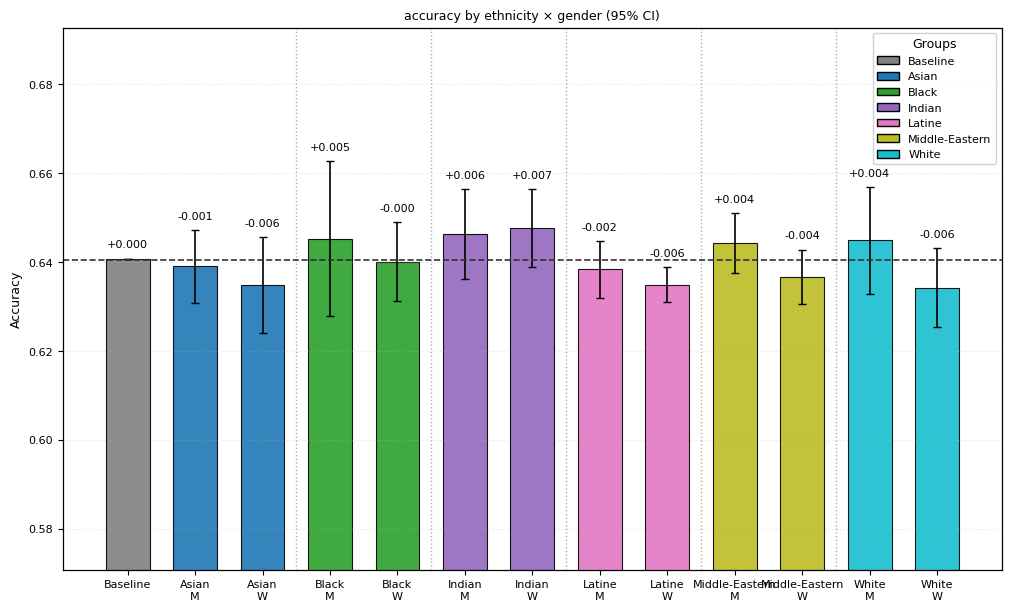

In [55]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (579, 65)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (579, 65)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.621762 - 0.664940
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.643005  0.008548
woman      30  0.638054  0.007693

ETHNICITY:
                count      mean       std
ethnicity                                
asian              10  0.636960  0.007585
black              10  0.642660  0.010876
indian        

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:666: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


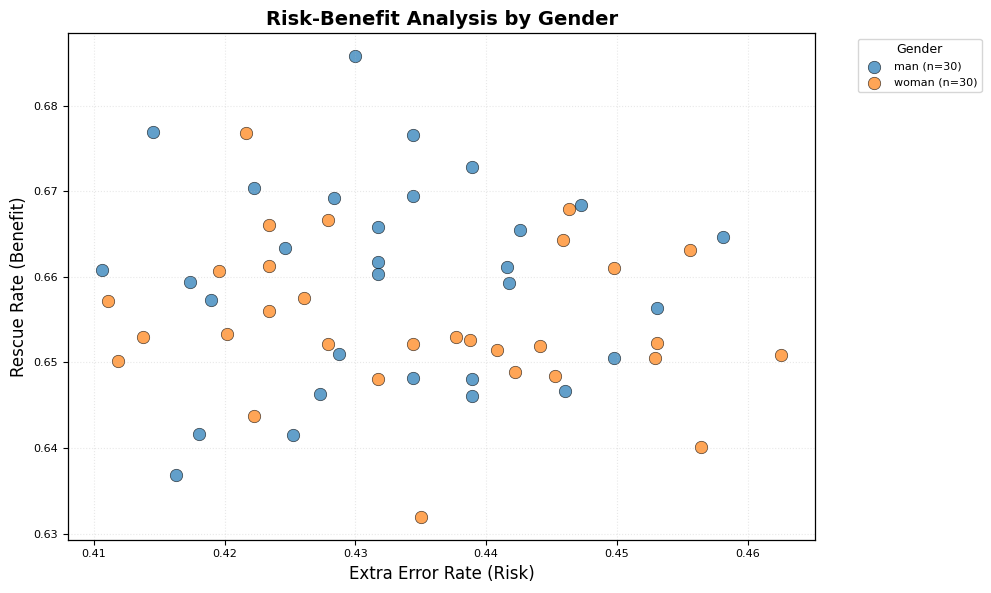


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


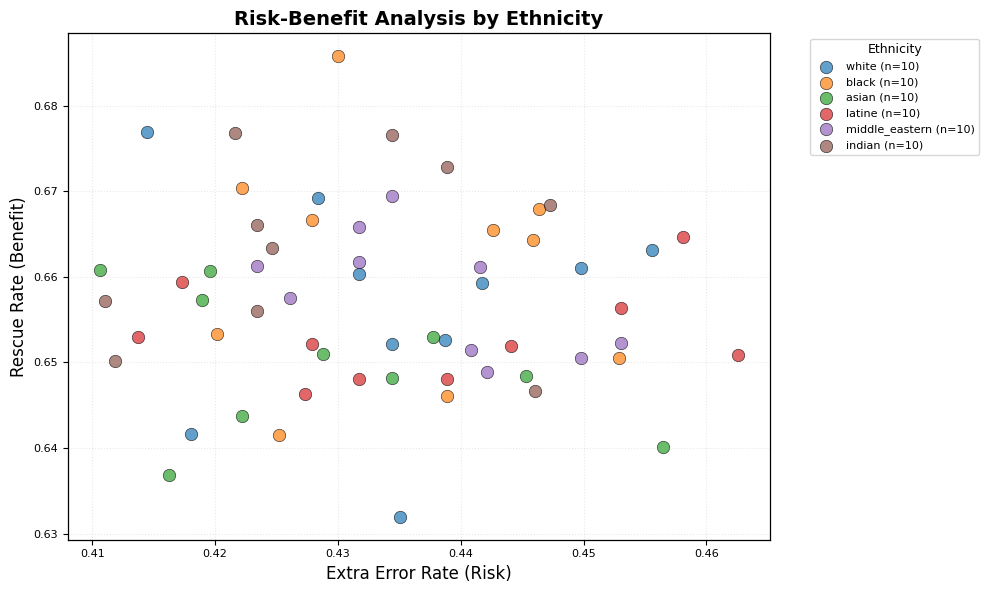


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:736: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


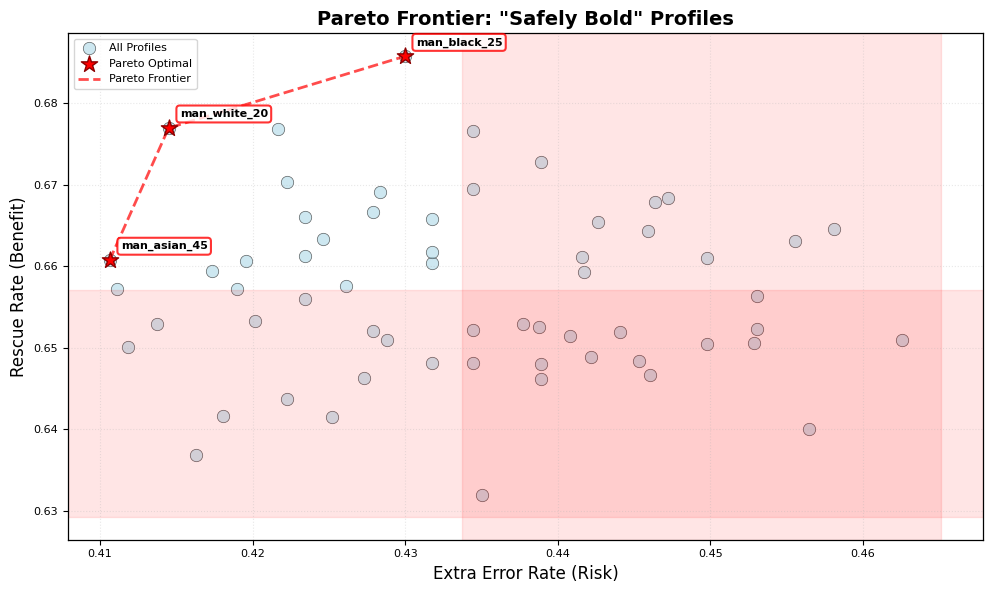


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (3 found):
  man_white_20 (profile1)
    Rescue Rate: 0.677, Extra Error Rate: 0.414
    Total Rescued: 297, Total Extra Errors: 60
  man_black_25 (profile12)
    Rescue Rate: 0.686, Extra Error Rate: 0.430
    Total Rescued: 303, Total Extra Errors: 62
  man_asian_45 (profile24)
    Rescue Rate: 0.661, Extra Error Rate: 0.411
    Total Rescued: 291, Total Extra Errors: 60

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.657
  Average extra error rate: 0.434
  Best rescue rate: 0.686
  Lowest extra error rate: 0.411

Profile Archetypes:
  Safest Profile: man_asian_45 (profile24)
    Extra Error Rate: 0.411
  Most Beneficial Profile: man_black_25 (profile12)
    Rescue Rate: 0.686

Demographic Composition of Pareto Optimal Profiles:
  Gender:
    man: 3 (100.0%)
  Ethnicity:
    white: 1 (33.3%)
    black: 1 (33.3%)
    asian: 1 (33.3%)
  Age:
=== Pareto frontier analysis completed successfully

S

In [56]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_full, case=mmlu_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (579, 65)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (579, 65)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.6408

Ensemble Performance by Trait Group:
----------

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


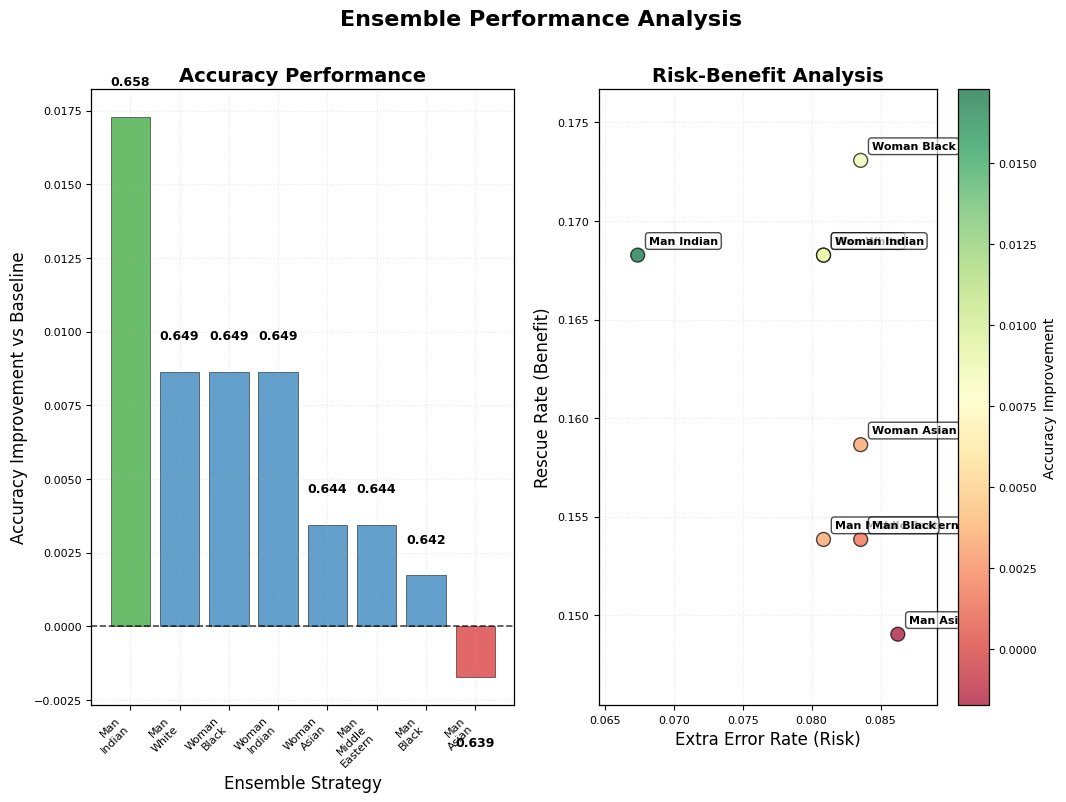

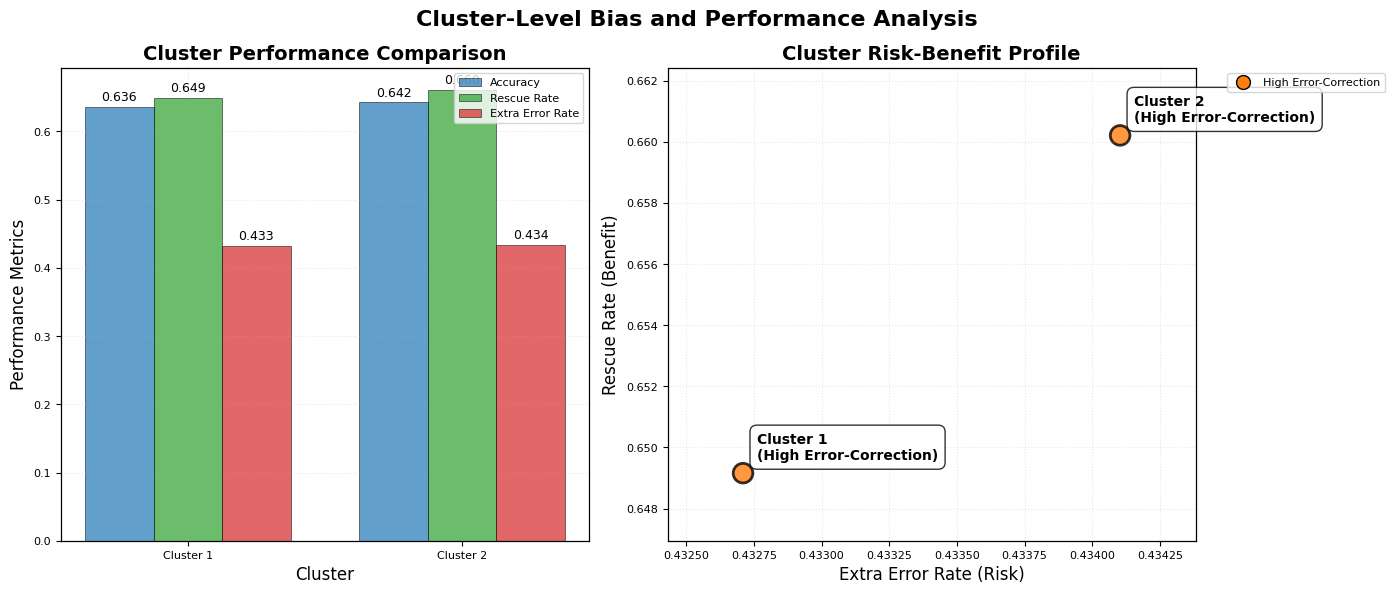

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


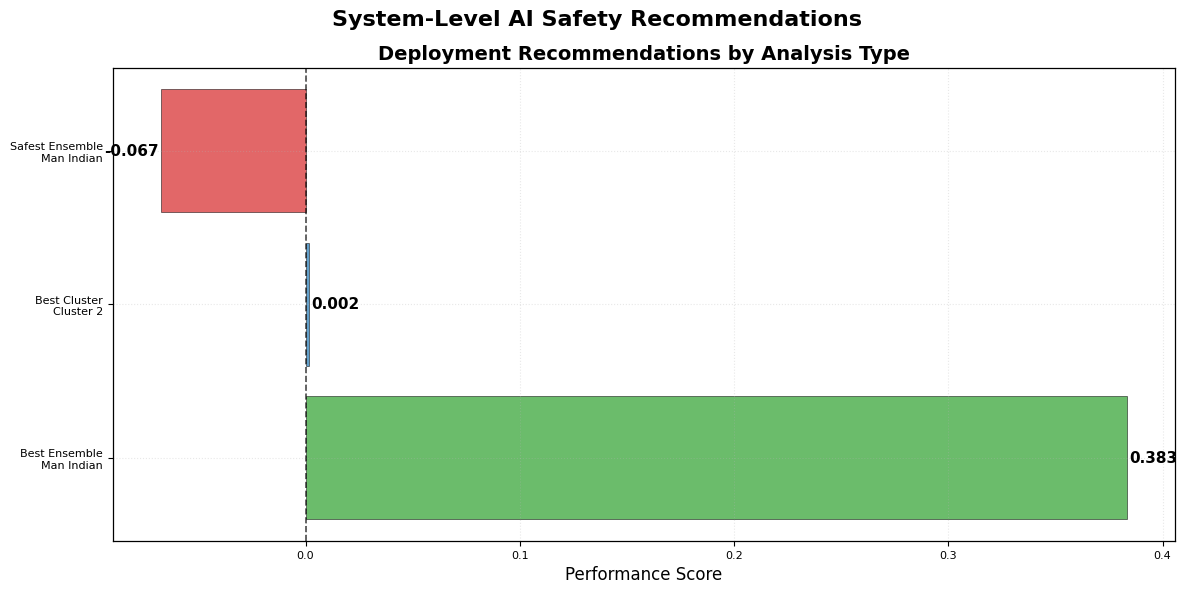


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: man_indian
   • Best Cluster: cluster_2
   • Cognitive style analysis skipped: No cognitive style data found


In [57]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
Found category values in subject: ['college_mathematics', 'formal_logic', 'moral_scenarios', 'professional_law']
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 11)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.091, p=0.4906 
    → Positive correlatio

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


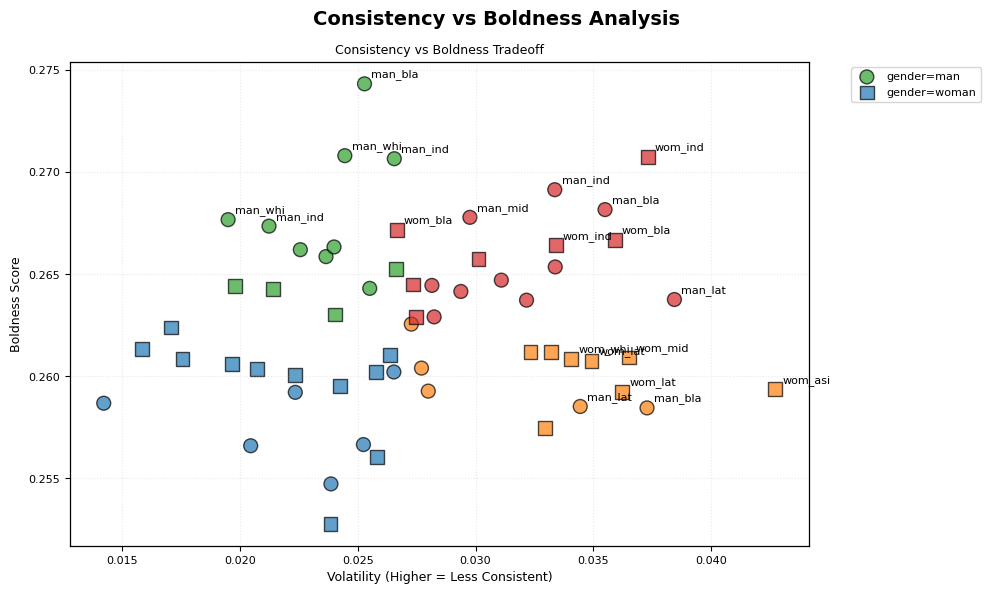

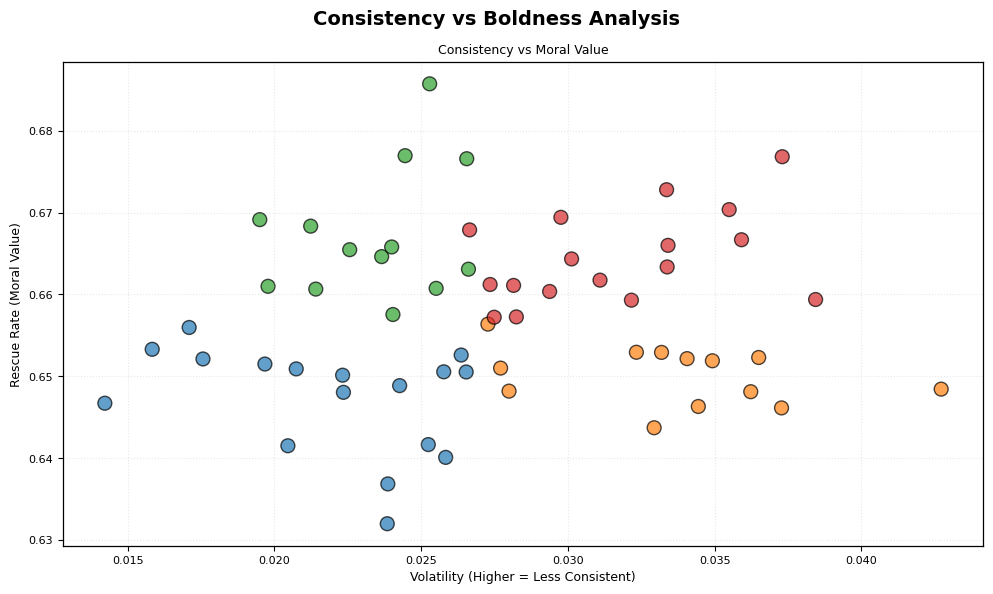

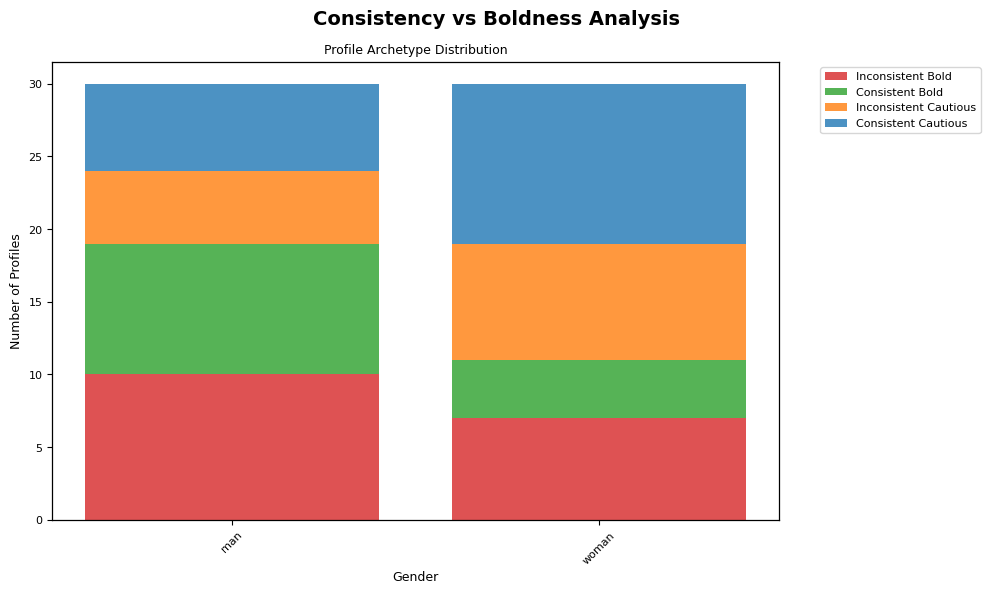

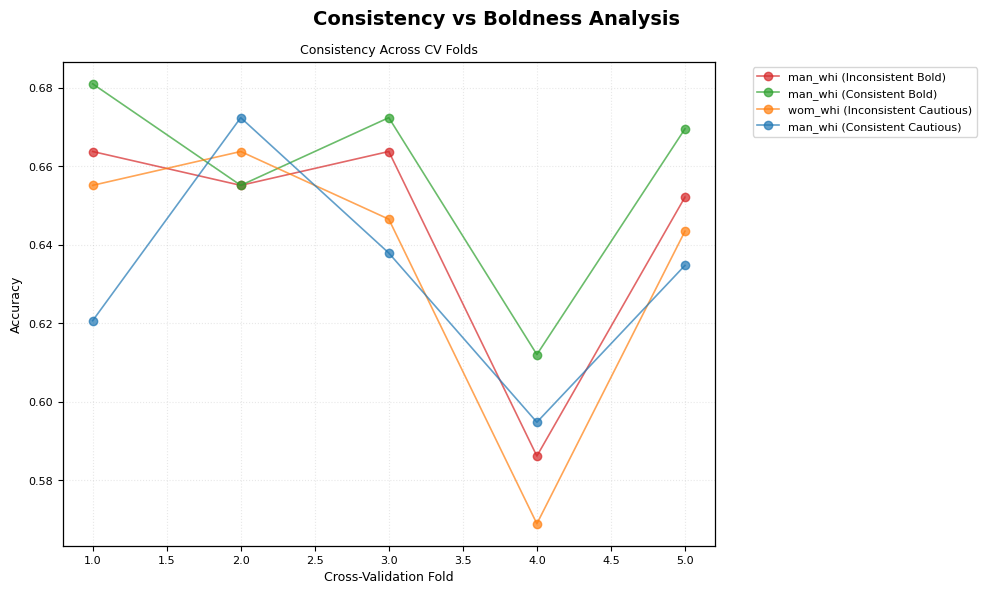

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.658 vs Consistent: 0.656
   - Strongest predictor of moral value (rescue): ethnicity_indian
   - Strongest predictor of performance (accuracy): ethnicity_indian
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 2 high, 0 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


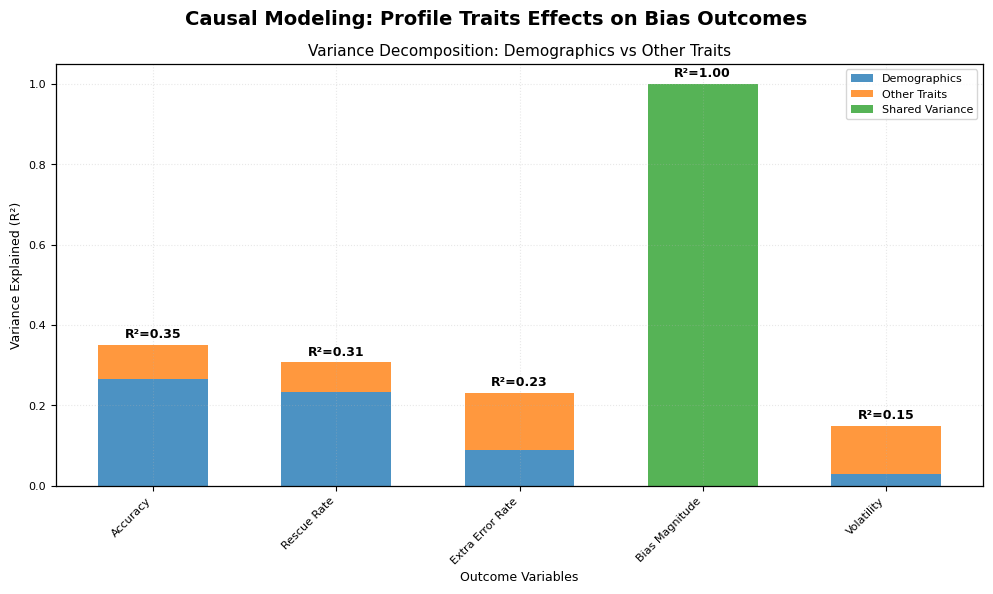

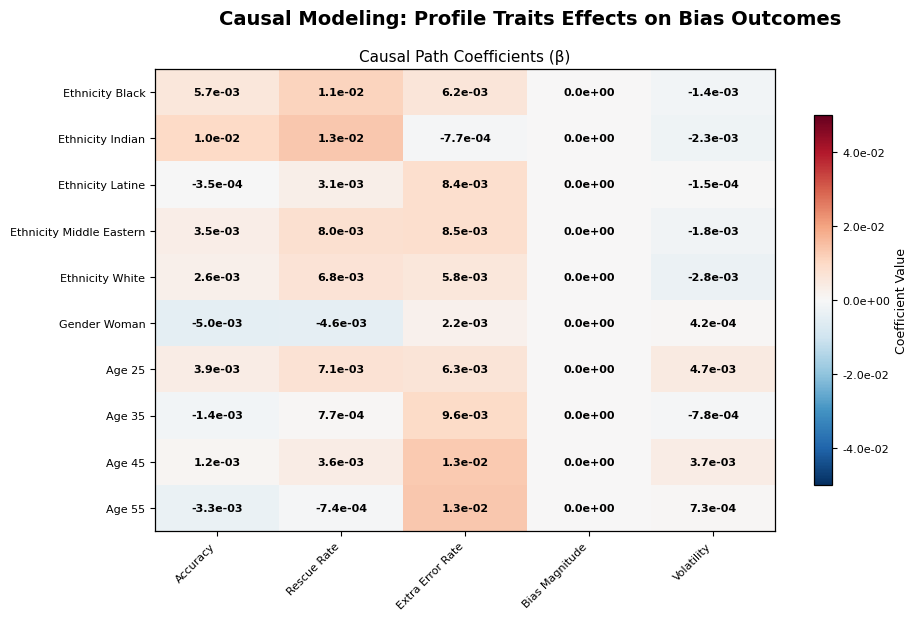

In [58]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_full, person_set=PERSON_ETHNICS, case=mmlu_case)

## Zero shot Normative Full

All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 8
Statistical Significance Rate: 25.0%

LARGEST EFFECT SIZES
----------------------------------------
 1. intersectional_middle_eastern_woman_vs_man Effect Size: -2.682 (Large)
 2. intersectional_white_woman_vs_man   Effect Size: -2.090 (Large)
 3. indian_vs_latine                    Effect Size:  1.951 (Large)
 4. indian_vs_white                     Effect Size:  1.694 (Large)
 5. asian_vs_indian                     Effect Size: -1.529 (Large)

DETAILED SIGNIFICANT RESULTS
[SIGNIFICANT] men_vs_women                        | Man: 0.653 | Woman: 0

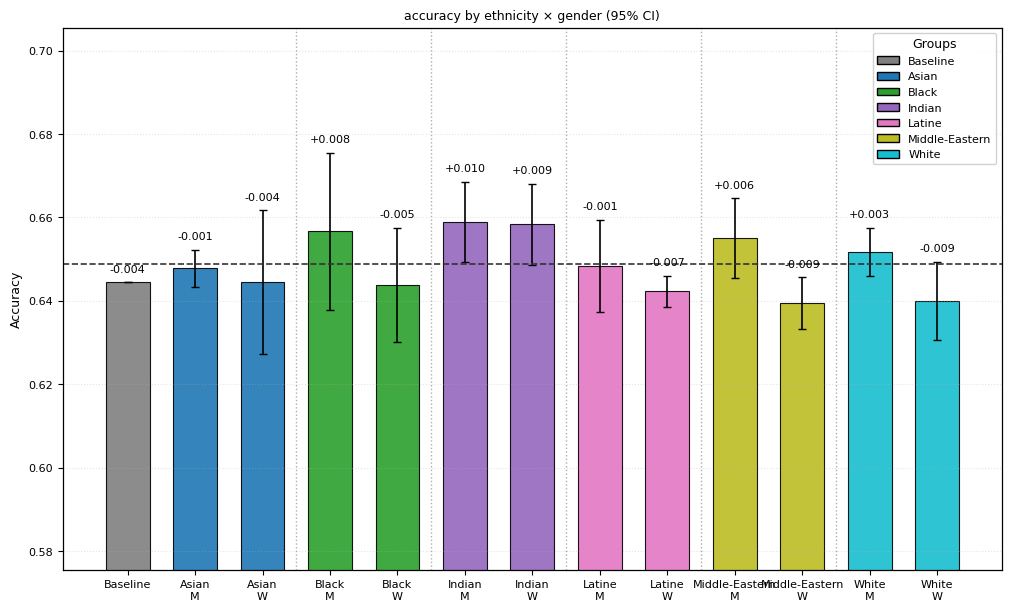

In [59]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_normative_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (360, 65)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (360, 65)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.622222 - 0.680556
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.653056  0.009033
woman      30  0.644722  0.010300

ETHNICITY:
                count      mean       std
ethnicity                                
asian              10  0.646111  0.009729
black              10  0.650278  0.014191
indian        

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:666: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


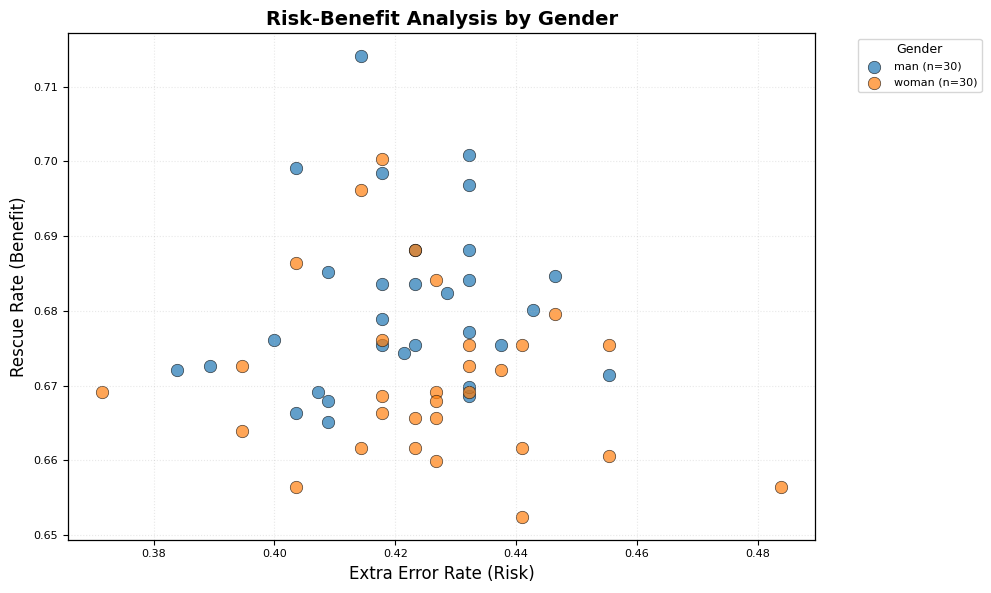


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


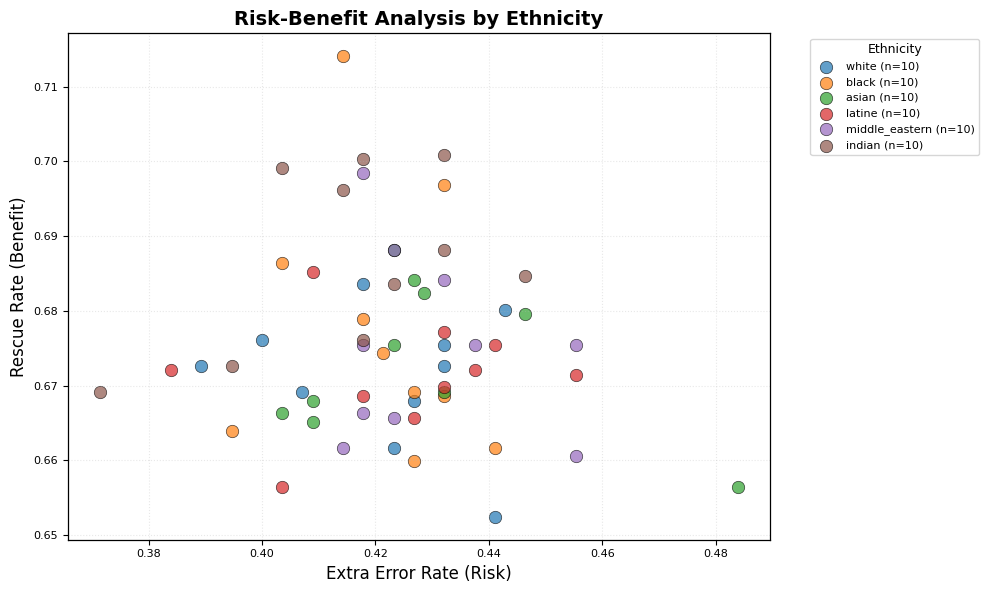


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:736: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


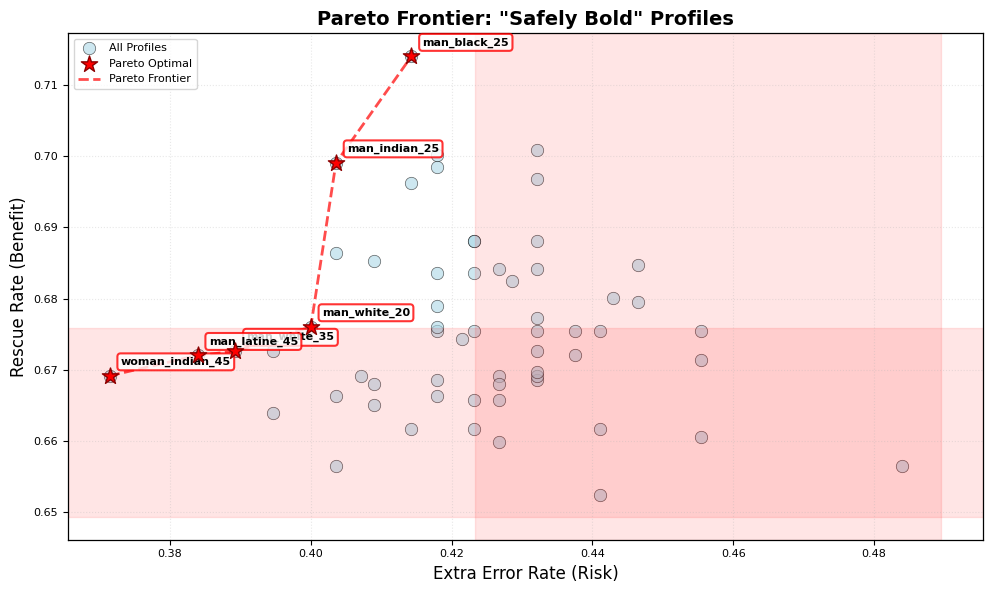


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (6 found):
  man_white_20 (profile1)
    Rescue Rate: 0.676, Extra Error Rate: 0.400
    Total Rescued: 182, Total Extra Errors: 37
  man_black_25 (profile12)
    Rescue Rate: 0.714, Extra Error Rate: 0.414
    Total Rescued: 192, Total Extra Errors: 38
  man_white_35 (profile3)
    Rescue Rate: 0.673, Extra Error Rate: 0.389
    Total Rescued: 181, Total Extra Errors: 37
  man_latine_45 (profile34)
    Rescue Rate: 0.672, Extra Error Rate: 0.384
    Total Rescued: 181, Total Extra Errors: 37
  man_indian_25 (profile52)
    Rescue Rate: 0.699, Extra Error Rate: 0.404
    Total Rescued: 188, Total Extra Errors: 38
  woman_indian_45 (profile59)
    Rescue Rate: 0.669, Extra Error Rate: 0.371
    Total Rescued: 180, Total Extra Errors: 35

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.676
  Average extra error rate: 0.423
  Best rescue rate: 0.714
  Lowest extra error rate: 0.371

Profile Archetyp

In [60]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_normative_full, case=mmlu_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (360, 65)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (360, 65)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.6444

Ensemble Performance by Trait Group:
----------

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


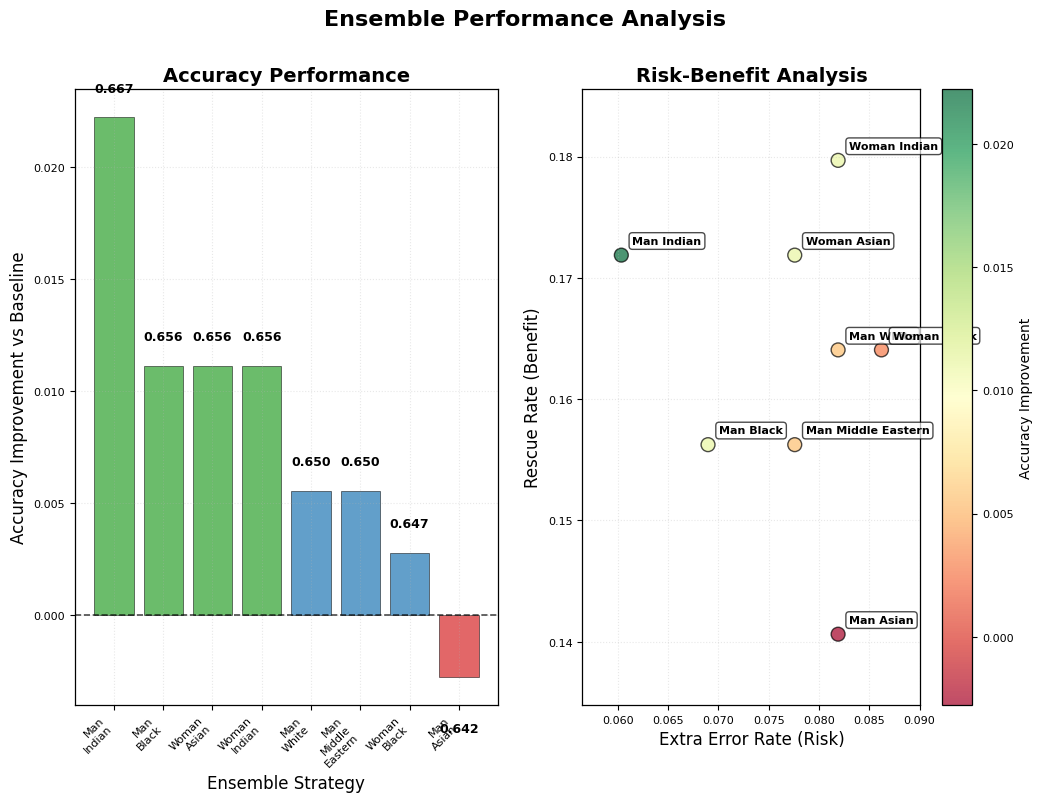

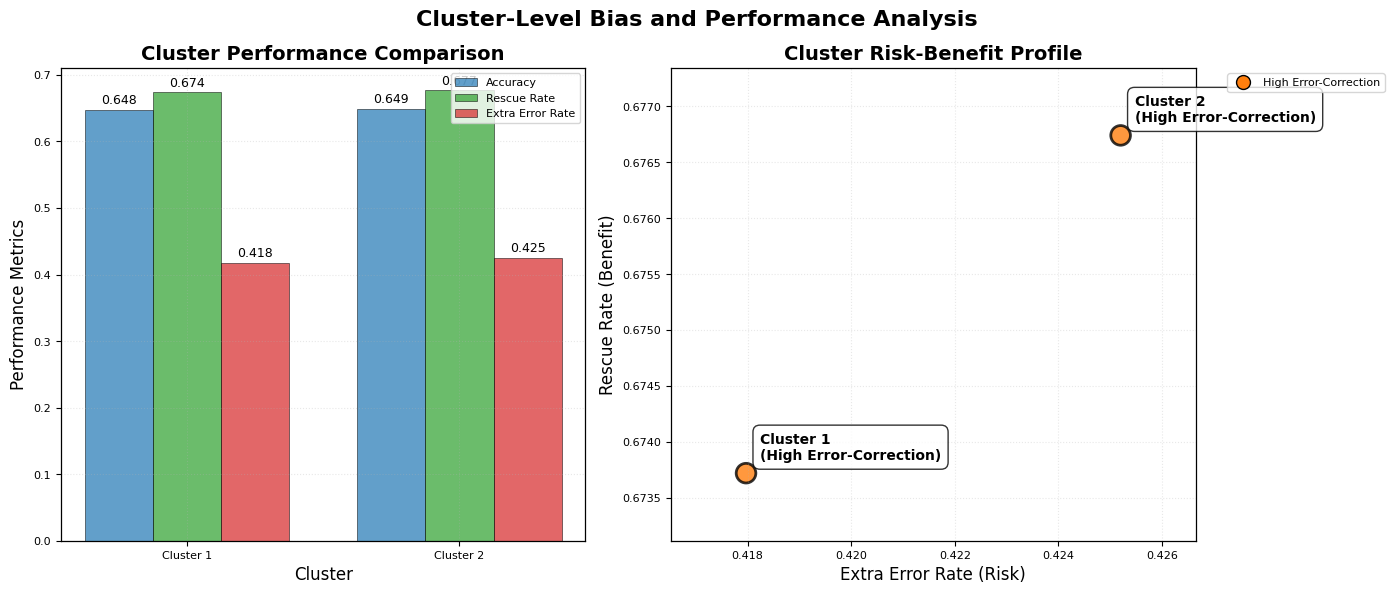

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


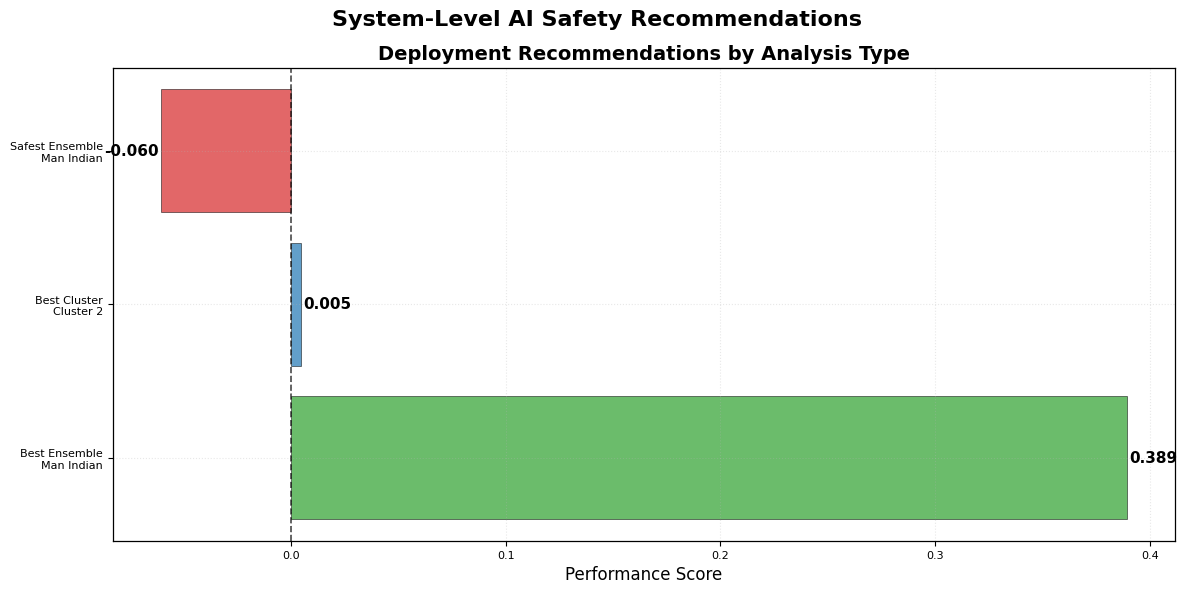


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: man_indian
   • Best Cluster: cluster_2
   • Cognitive style analysis skipped: No cognitive style data found


In [61]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_normative_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
Found category values in subject: ['moral_scenarios', 'professional_law']
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 11)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.259, p=0.0455 ***
    → Positive correlation means less consistent profiles are

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


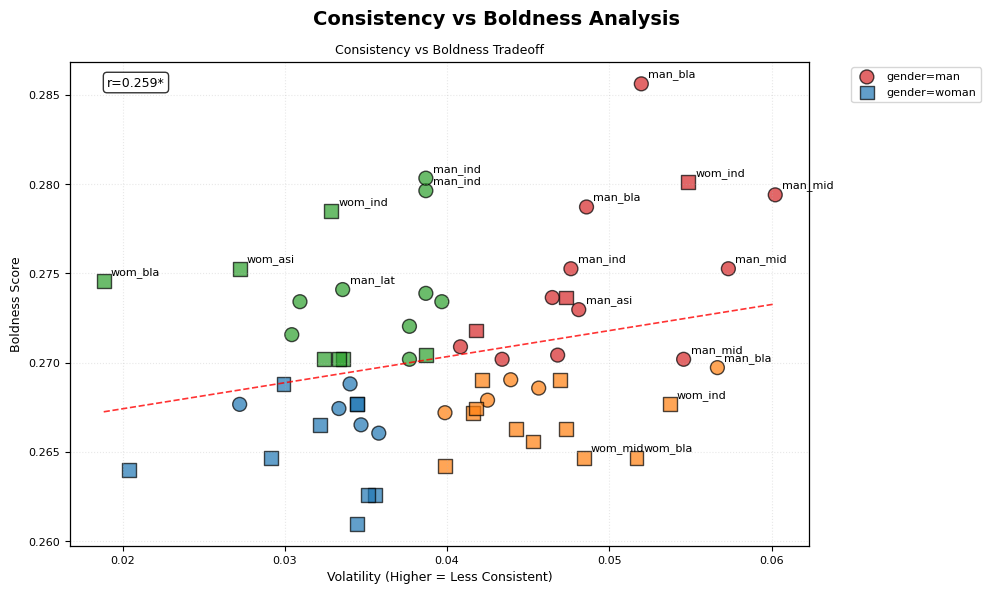

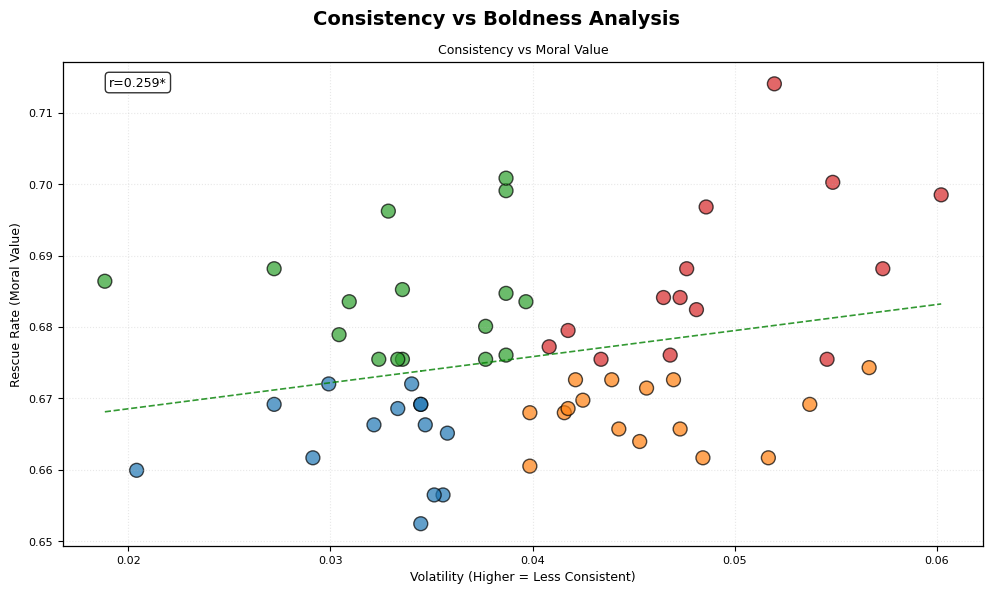

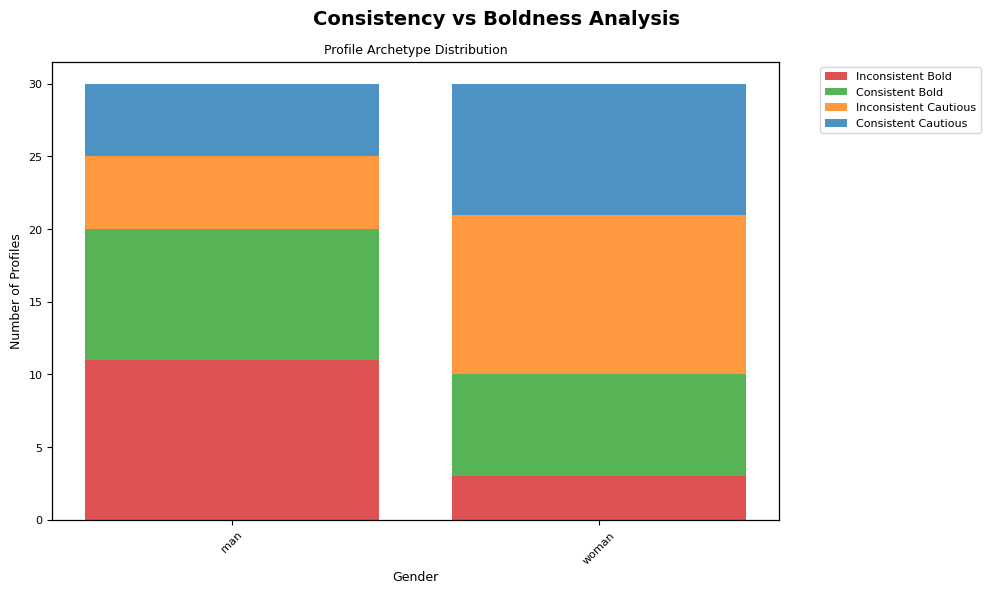

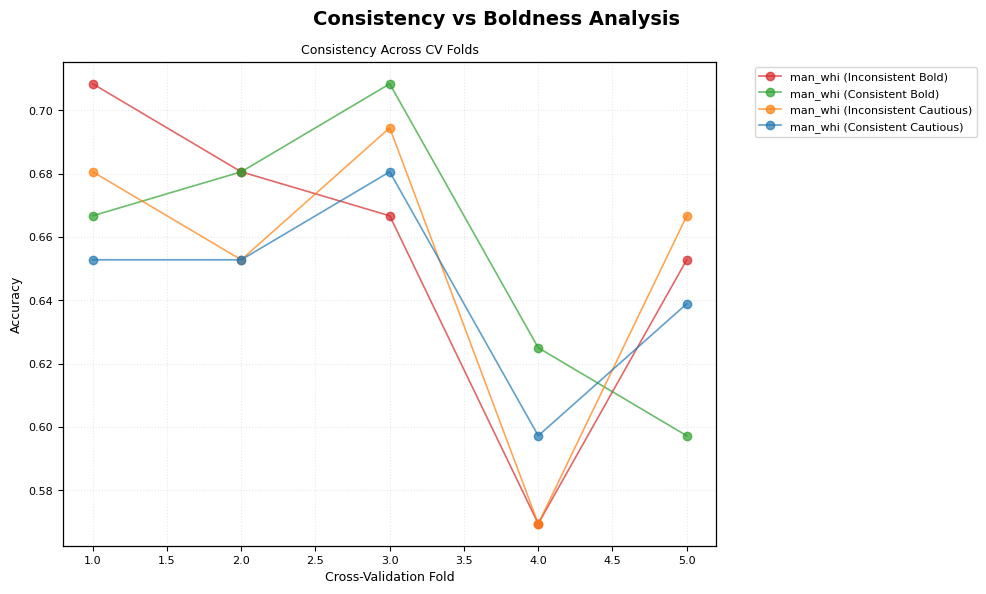

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.677 vs Consistent: 0.675
   - Strongest predictor of moral value (rescue): ethnicity_indian
   - Strongest predictor of performance (accuracy): ethnicity_indian
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 2 high, 1 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


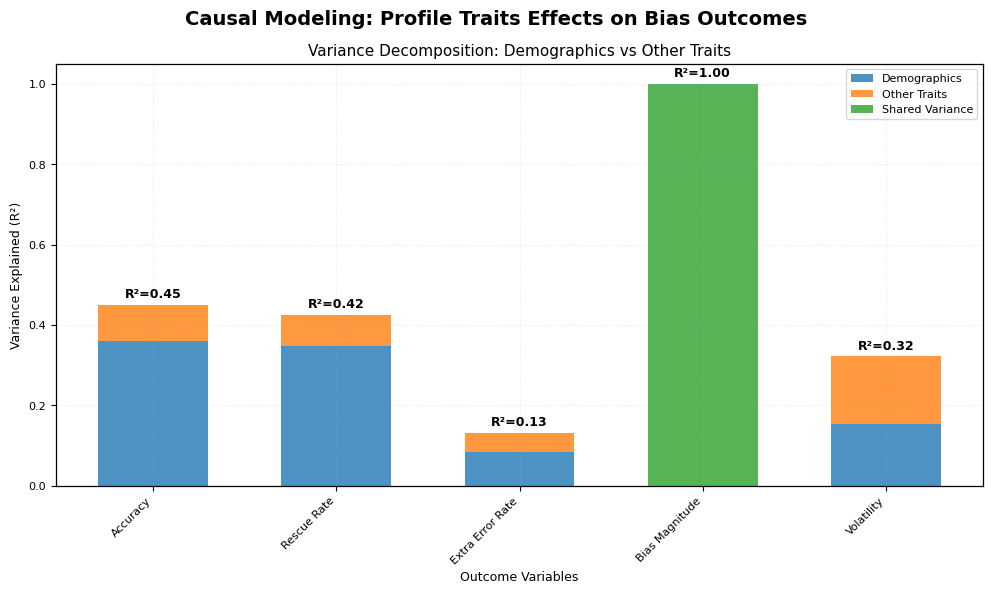

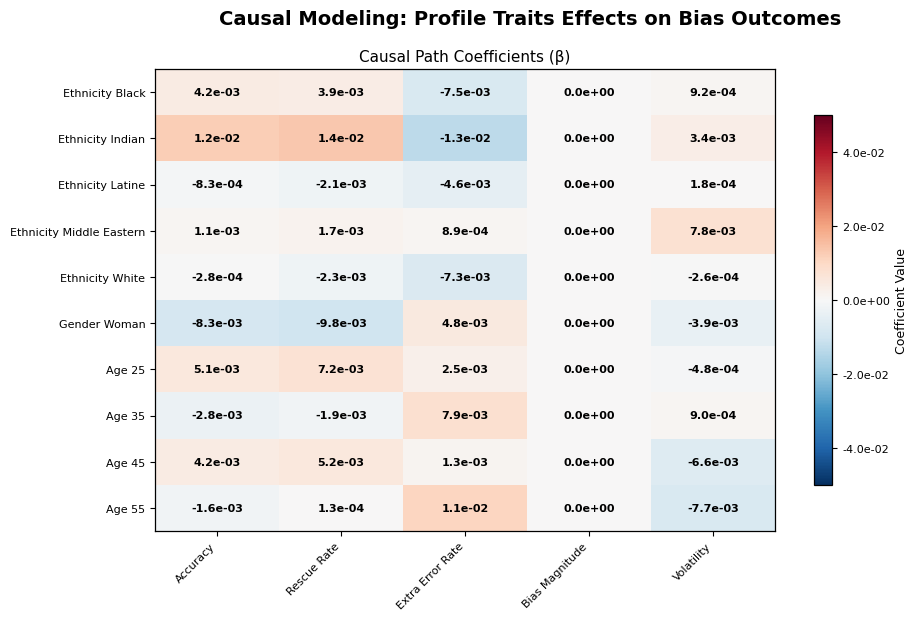

In [62]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_normative_full, person_set=PERSON_ETHNICS, case=mmlu_case)

## Zero shot Control Full

All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 0
Statistical Significance Rate: 0.0%

LARGEST EFFECT SIZES
----------------------------------------
 1. intersectional_white_woman_vs_man   Effect Size: -0.692 (Medium)
 2. age_age.age_2_vs_age.age_5          Effect Size:  0.642 (Medium)
 3. black_vs_latine                     Effect Size:  0.633 (Medium)
 4. latine_vs_middle_eastern            Effect Size: -0.618 (Medium)
 5. asian_vs_black                      Effect Size: -0.594 (Medium)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.626 | Wom

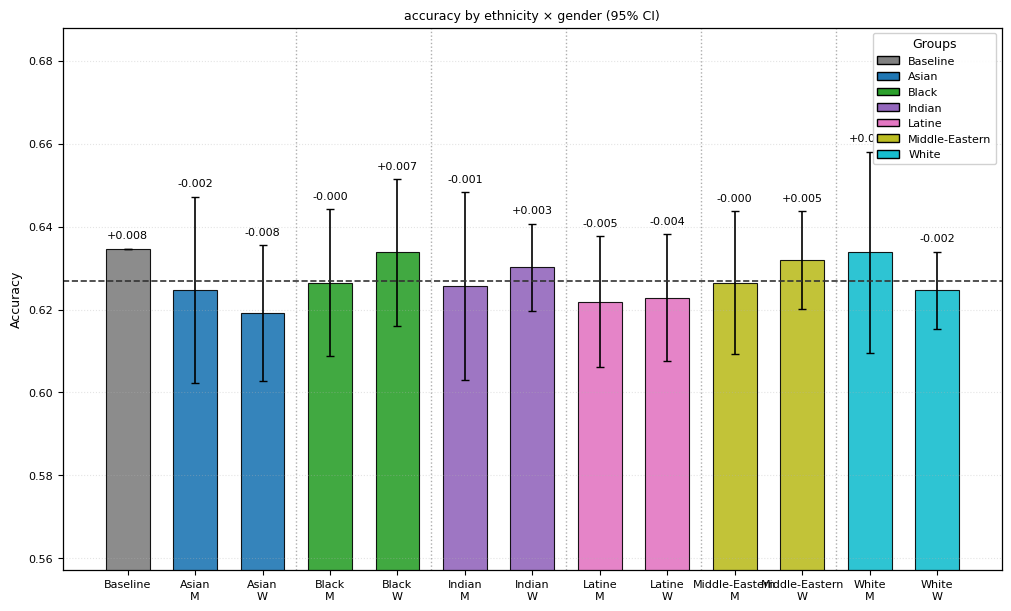

In [63]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_control_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (219, 65)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (219, 65)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.598174 - 0.662100
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.626484  0.015281
woman      30  0.627093  0.011460

ETHNICITY:
                count      mean       std
ethnicity                                
asian              10  0.621918  0.015190
black              10  0.630137  0.013950
indian        

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:666: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


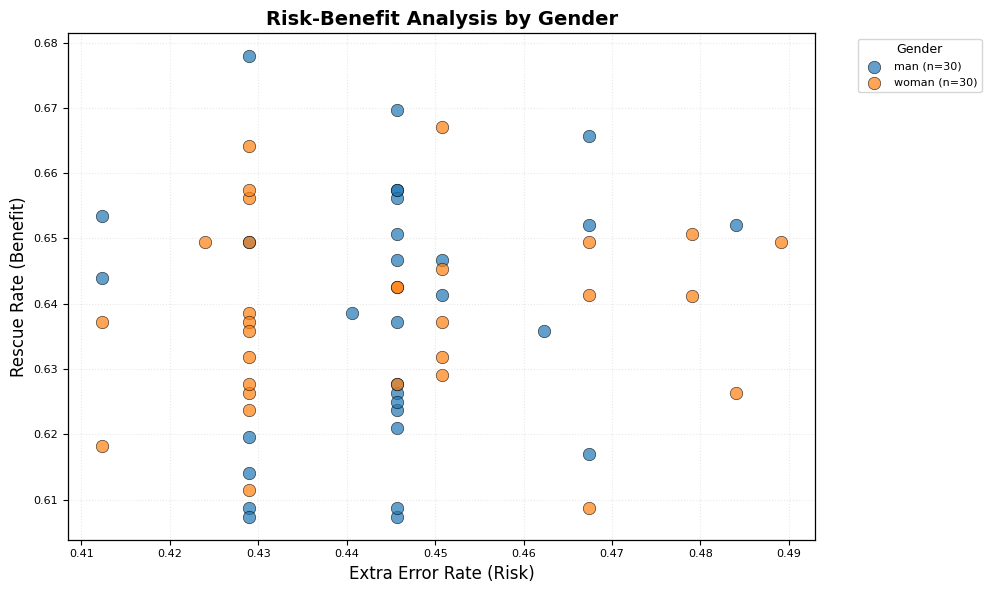


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


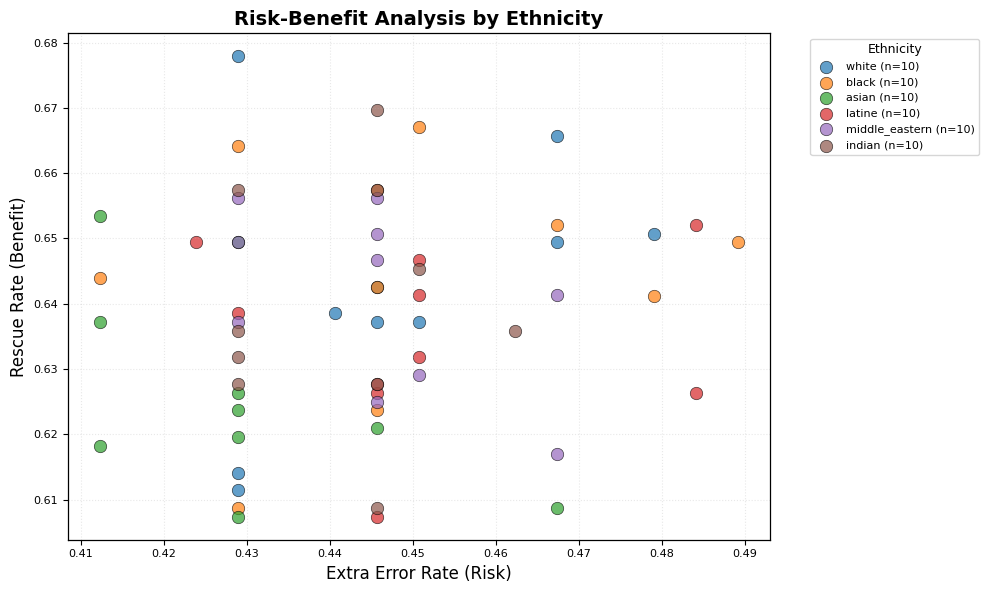


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:736: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


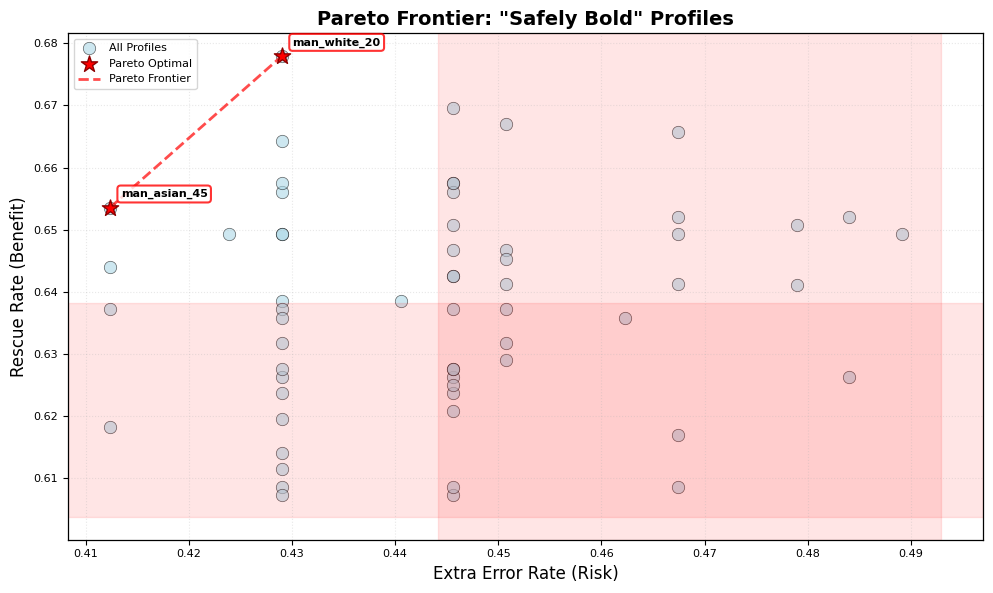


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (2 found):
  man_white_20 (profile1)
    Rescue Rate: 0.678, Extra Error Rate: 0.429
    Total Rescued: 115, Total Extra Errors: 23
  man_asian_45 (profile24)
    Rescue Rate: 0.653, Extra Error Rate: 0.412
    Total Rescued: 111, Total Extra Errors: 22

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.638
  Average extra error rate: 0.444
  Best rescue rate: 0.678
  Lowest extra error rate: 0.412

Profile Archetypes:
  Safest Profile: man_black_20 (profile11)
    Extra Error Rate: 0.412
  Most Beneficial Profile: man_white_20 (profile1)
    Rescue Rate: 0.678

Demographic Composition of Pareto Optimal Profiles:
  Gender:
    man: 2 (100.0%)
  Ethnicity:
    white: 1 (50.0%)
    asian: 1 (50.0%)
  Age:
=== Pareto frontier analysis completed successfully

STEP 3: EFFECT SIZE CALCULATIONS
CALCULATING ANOVA-BASED EFFECT SIZES

MAIN EFFECTS FROM ANOVA
----------------------------------------

INTERACT

In [64]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_control_full, case=mmlu_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (219, 65)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (219, 65)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.6347

Ensemble Performance by Trait Group:
----------

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


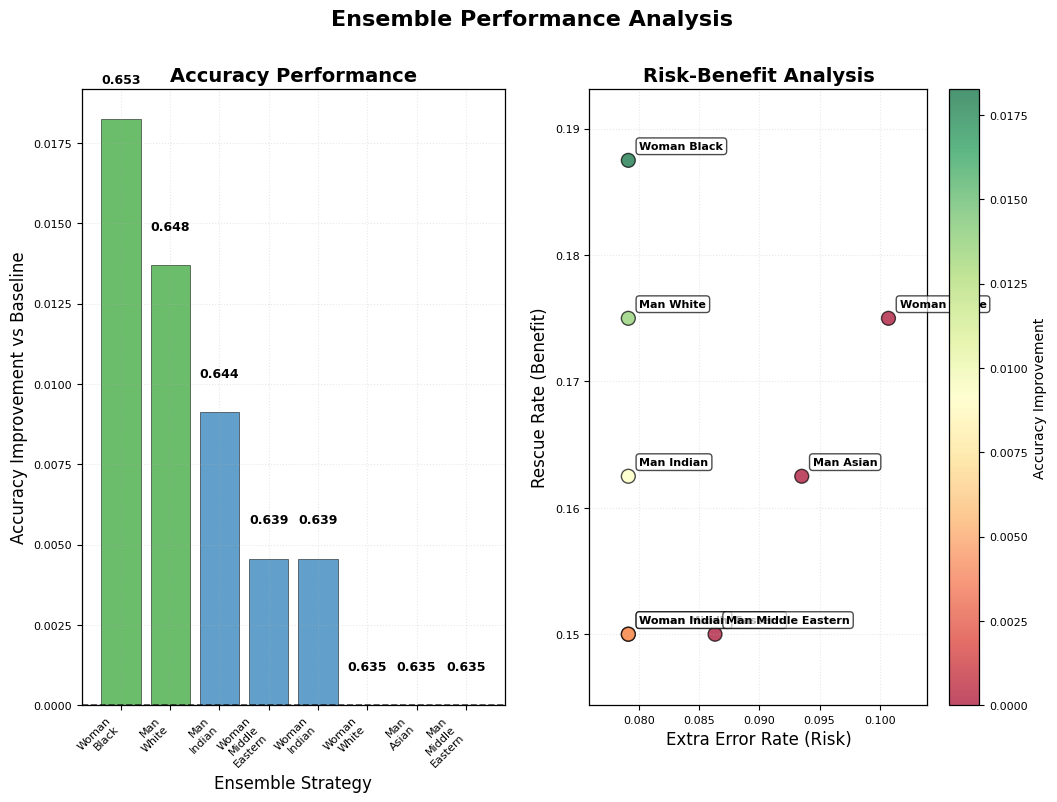

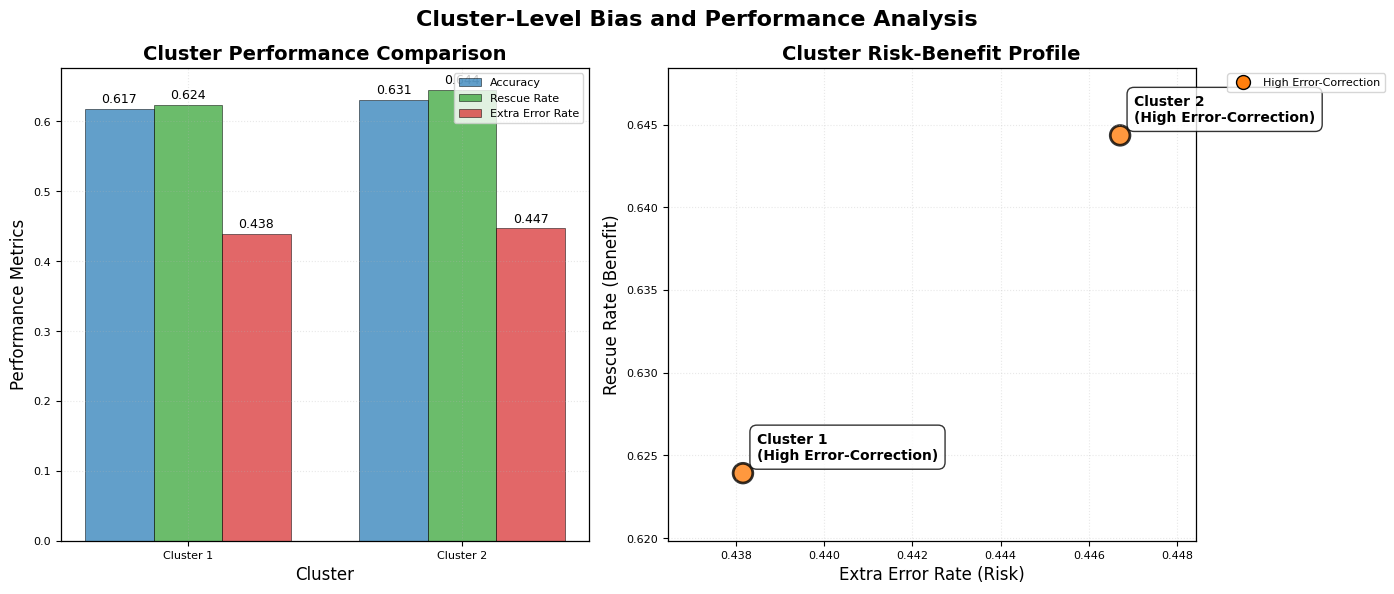

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


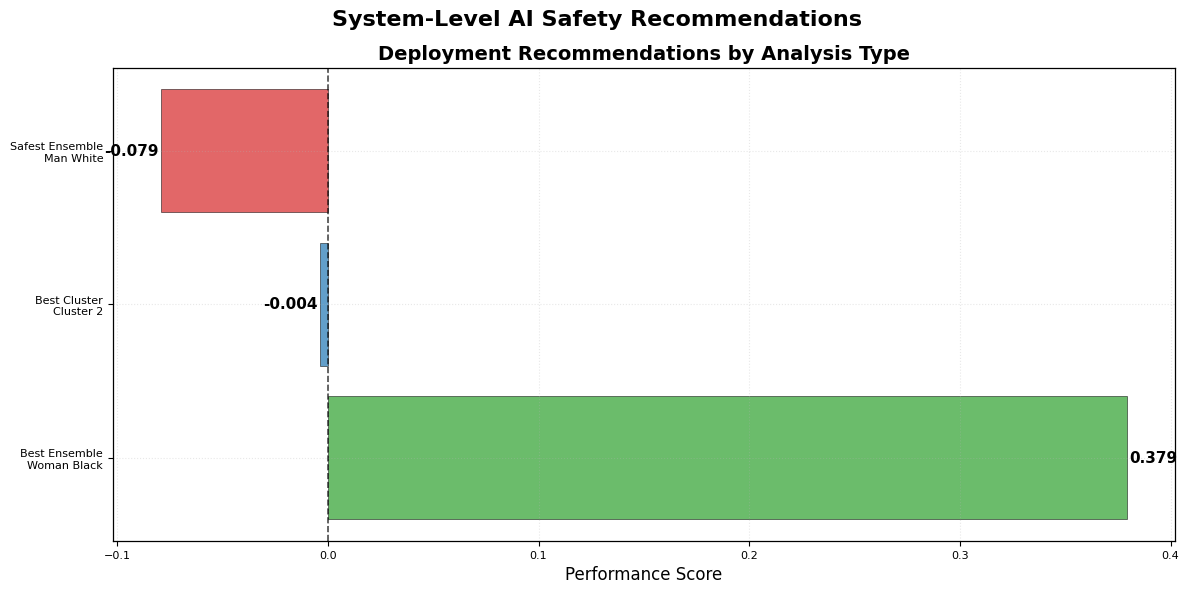


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: woman_black
   • Best Cluster: cluster_2
   • Cognitive style analysis skipped: No cognitive style data found


In [65]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_control_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
Found category values in subject: ['college_mathematics', 'formal_logic']
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 11)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.007, p=0.9571 
    → Positive correlation means less consistent profiles are bo

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


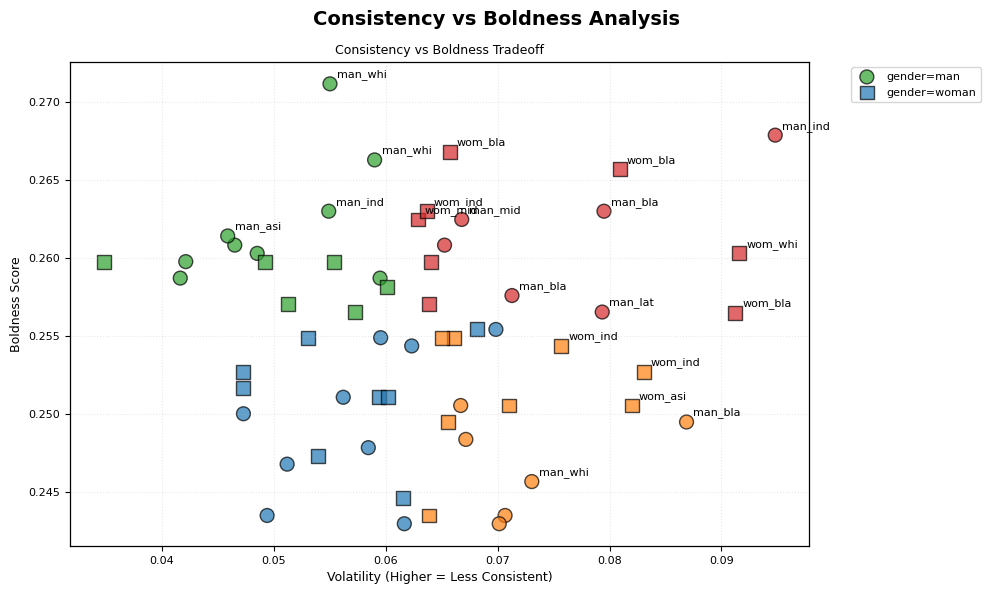

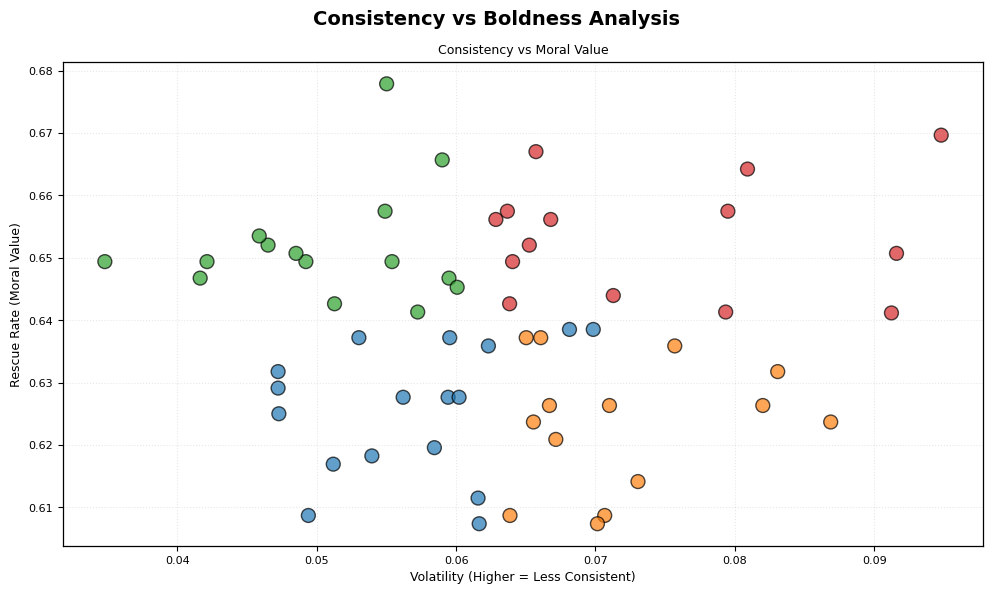

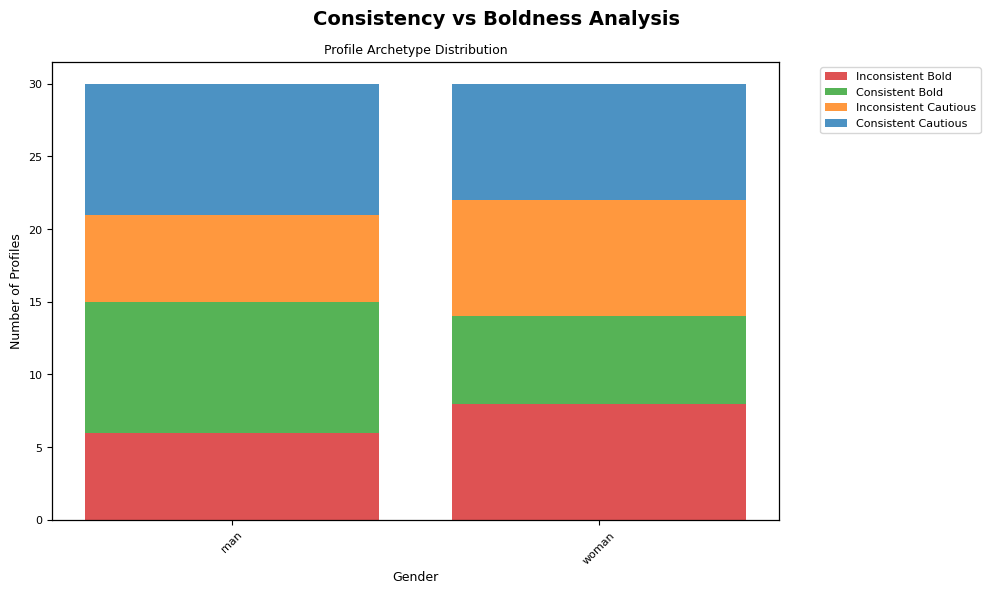

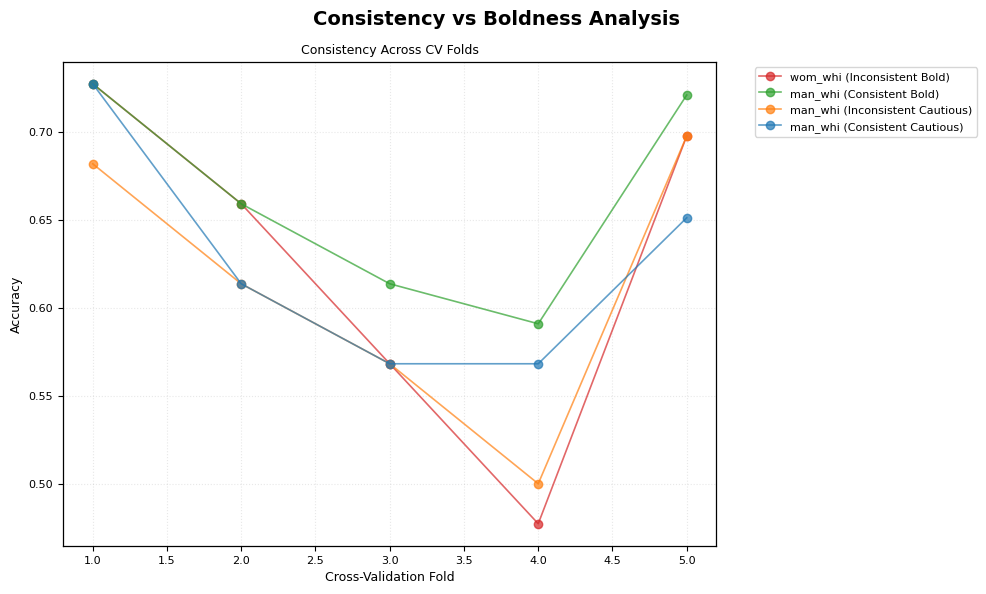

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.638 vs Consistent: 0.638
   - Strongest predictor of moral value (rescue): ethnicity_black
   - Strongest predictor of performance (accuracy): ethnicity_black
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 1 high, 1 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


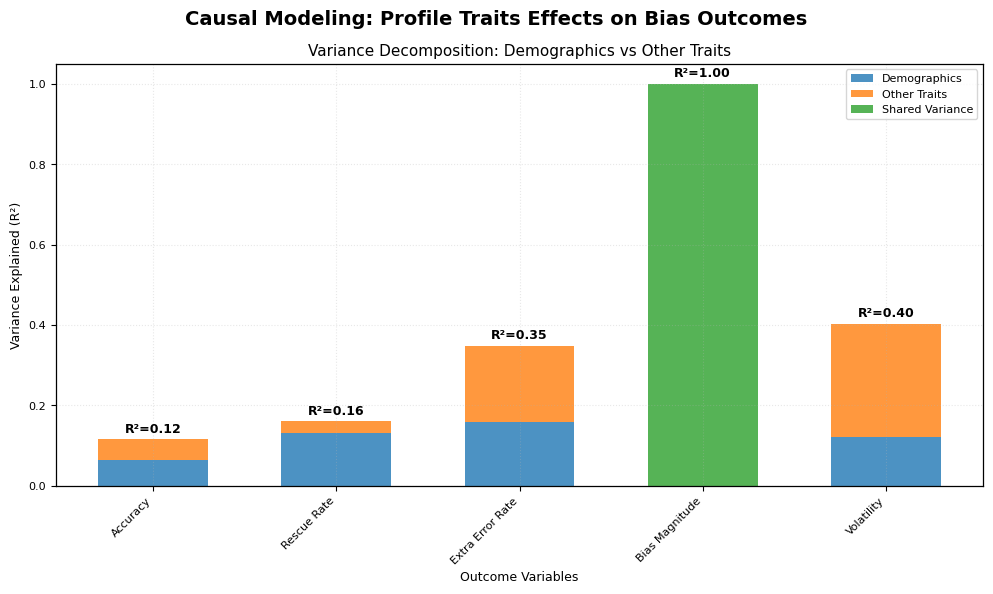

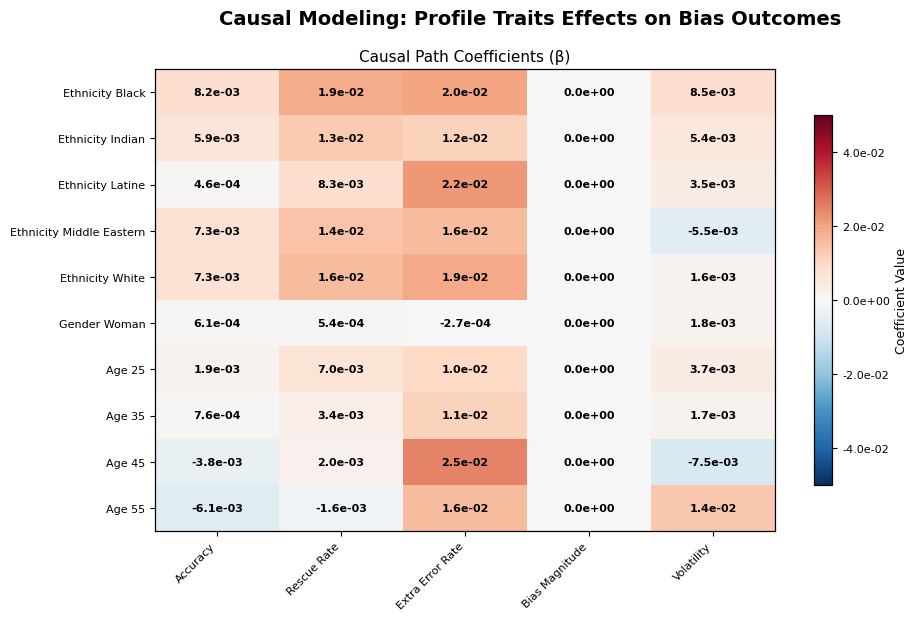

In [66]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_control_full, person_set=PERSON_ETHNICS, case=mmlu_case)

# Few Shot - Full Dataset

## Few shot Full

On both control and normative categories.

In [82]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df_full = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_mmlu_few_shot_3examples_full.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_mmlu_few_shot_3examples_full.csv",
    sample_df=sample_mmlu_full,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_control_full = merged_df_full.loc[merged_df_full["category"] == "control"]
merged_df_normative_full = merged_df_full.loc[merged_df_full["category"] == "normative"]

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'subject', 'category', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 4
Statistical Significance Rate: 12.5%

LARGEST EFFECT SIZES
----------------------------------------
 1. intersectional_indian_woman_vs_man  Effect Size: -2.129 (Large)
 2. asian_vs_indian                     Effect Size: -1.191 (Large)
 3. indian_vs_middle_eastern            Effect Size:  1.060 (Large)
 4. indian_vs_latine                    Effect Size:  1.019 (Large)
 5. black_vs_indian                     Effect Size: -0.954 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.643 | Woman: 

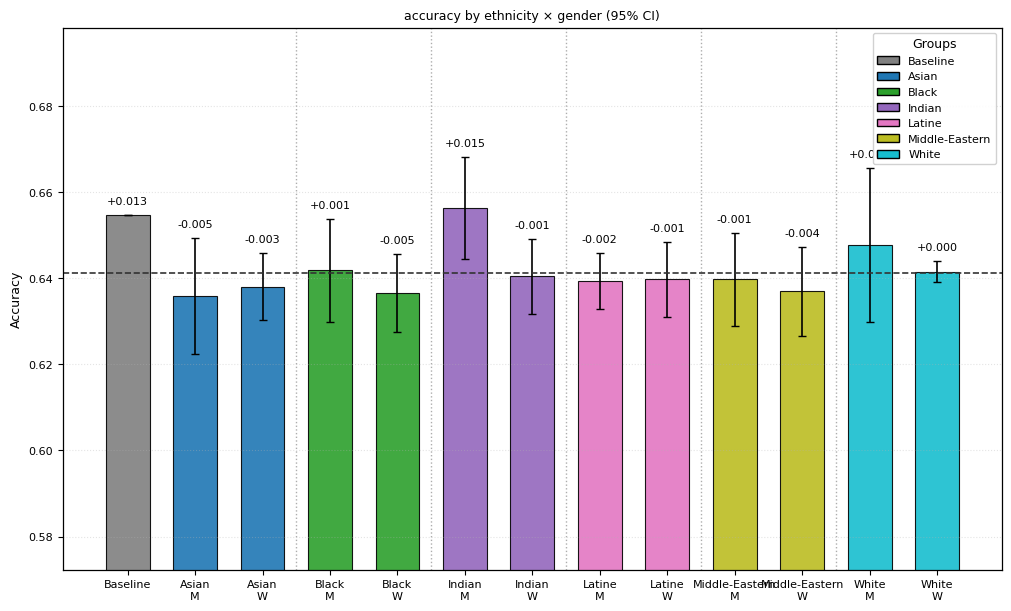

In [83]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (579, 65)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (579, 65)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.623489 - 0.666667
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean      std
gender                          
man        30  0.643466  0.01148
woman      30  0.638860  0.00629

ETHNICITY:
                count      mean       std
ethnicity                                
asian              10  0.636960  0.008453
black              10  0.639206  0.008518
indian            

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:666: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


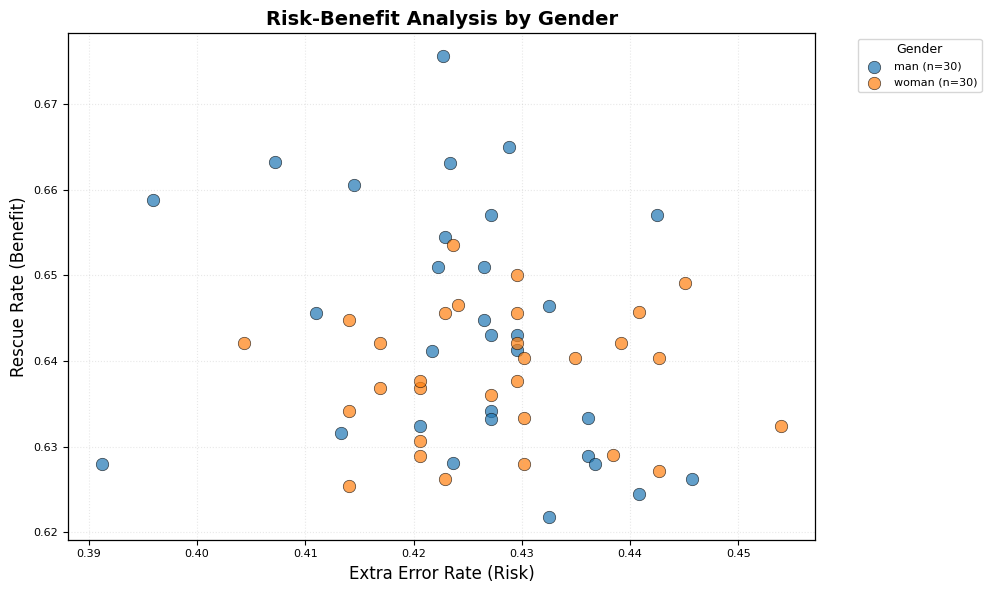


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


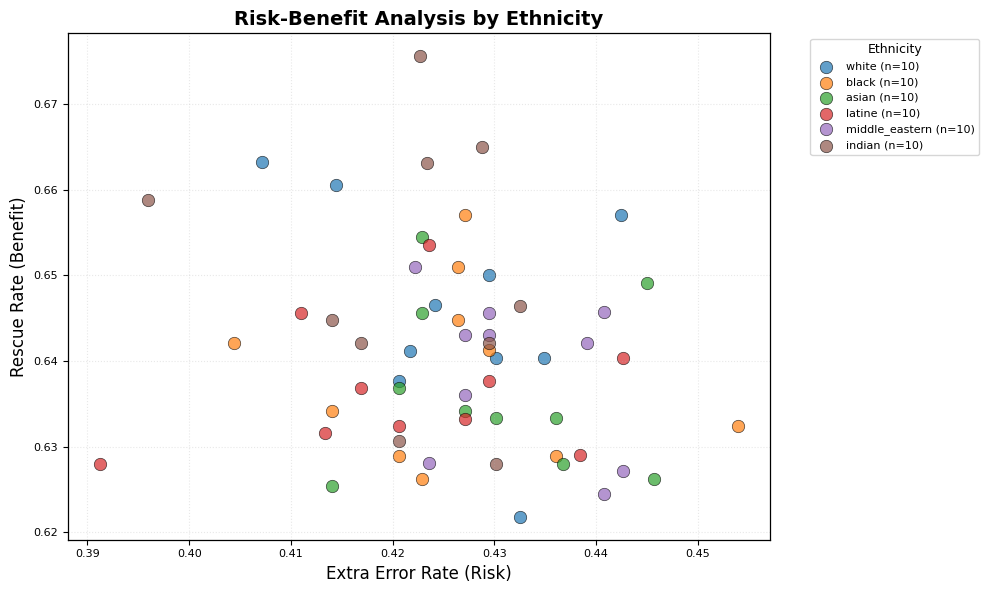


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:736: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


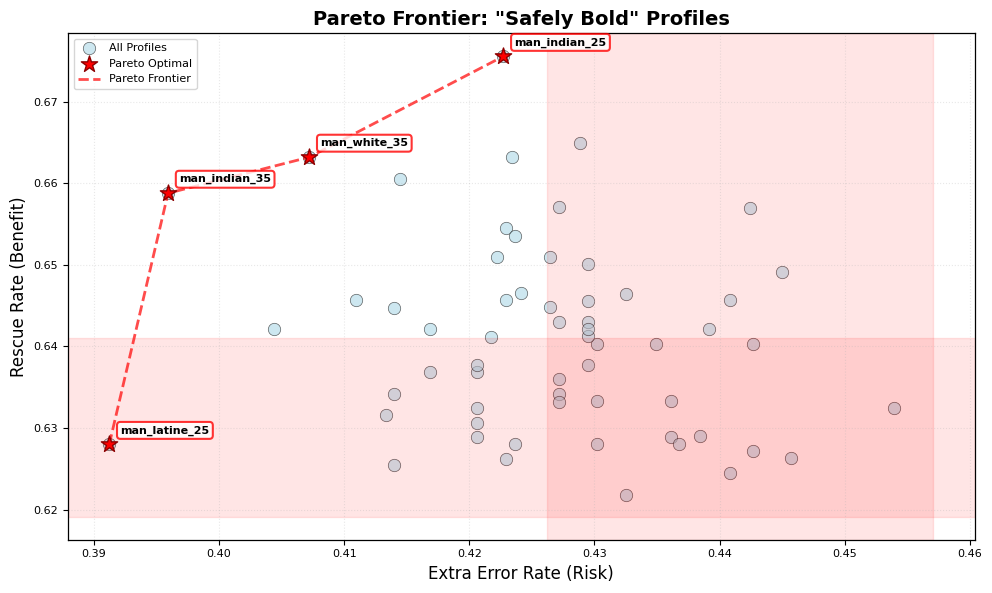


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (4 found):
  man_white_35 (profile3)
    Rescue Rate: 0.663, Extra Error Rate: 0.407
    Total Rescued: 305, Total Extra Errors: 51
  man_latine_25 (profile32)
    Rescue Rate: 0.628, Extra Error Rate: 0.391
    Total Rescued: 291, Total Extra Errors: 50
  man_indian_25 (profile52)
    Rescue Rate: 0.676, Extra Error Rate: 0.423
    Total Rescued: 309, Total Extra Errors: 53
  man_indian_35 (profile53)
    Rescue Rate: 0.659, Extra Error Rate: 0.396
    Total Rescued: 302, Total Extra Errors: 50

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.641
  Average extra error rate: 0.426
  Best rescue rate: 0.676
  Lowest extra error rate: 0.391

Profile Archetypes:
  Safest Profile: man_latine_25 (profile32)
    Extra Error Rate: 0.391
  Most Beneficial Profile: man_indian_25 (profile52)
    Rescue Rate: 0.676

Demographic Composition of Pareto Optimal Profiles:
  Gender:
    man: 4 (100.0%)
  Ethnicit

In [84]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_full, case=mmlu_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (579, 65)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (579, 65)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.6546

Ensemble Performance by Trait Group:
----------

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


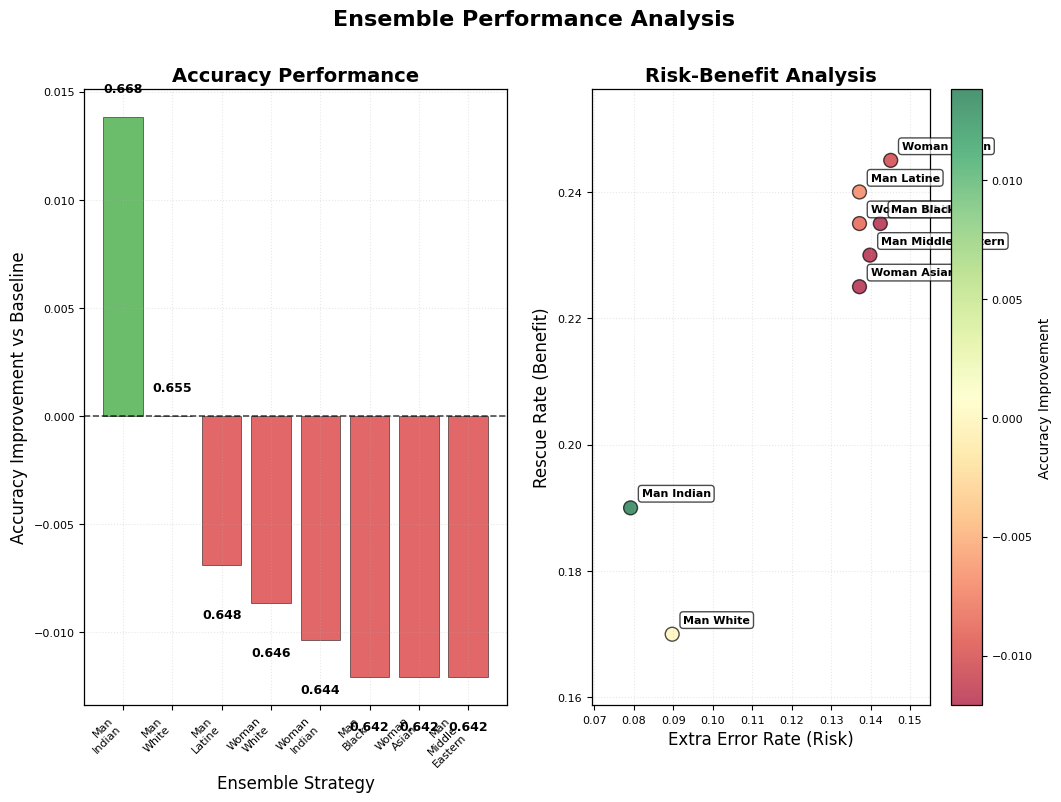

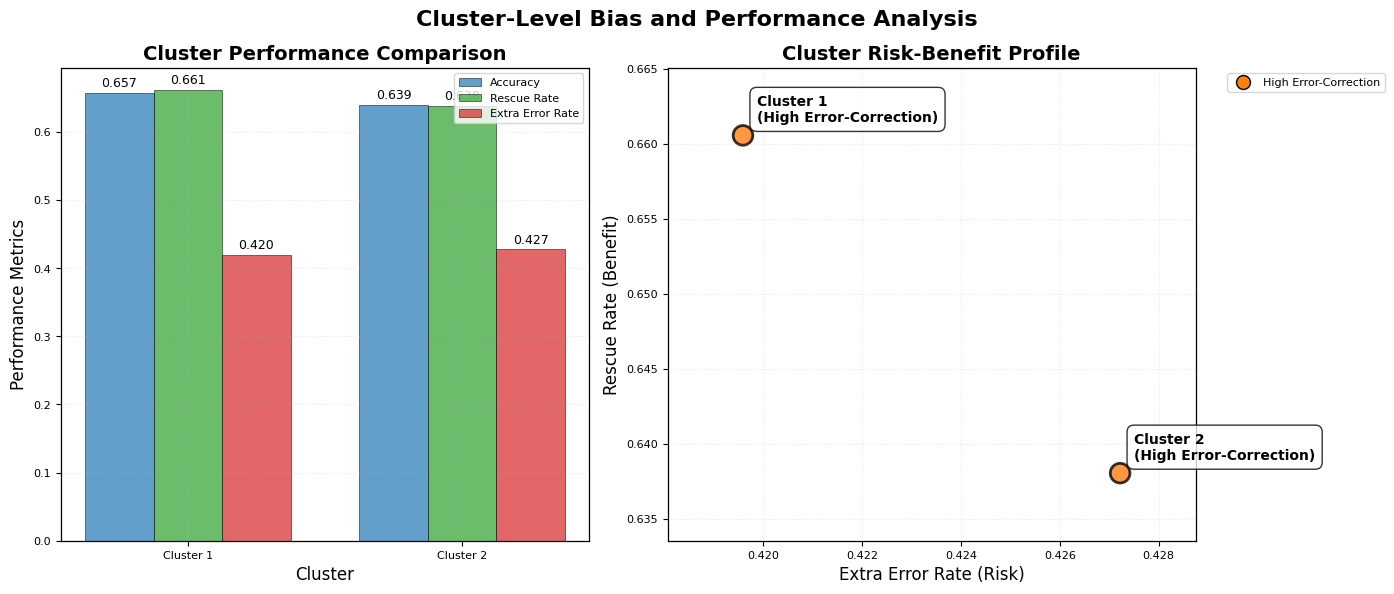

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


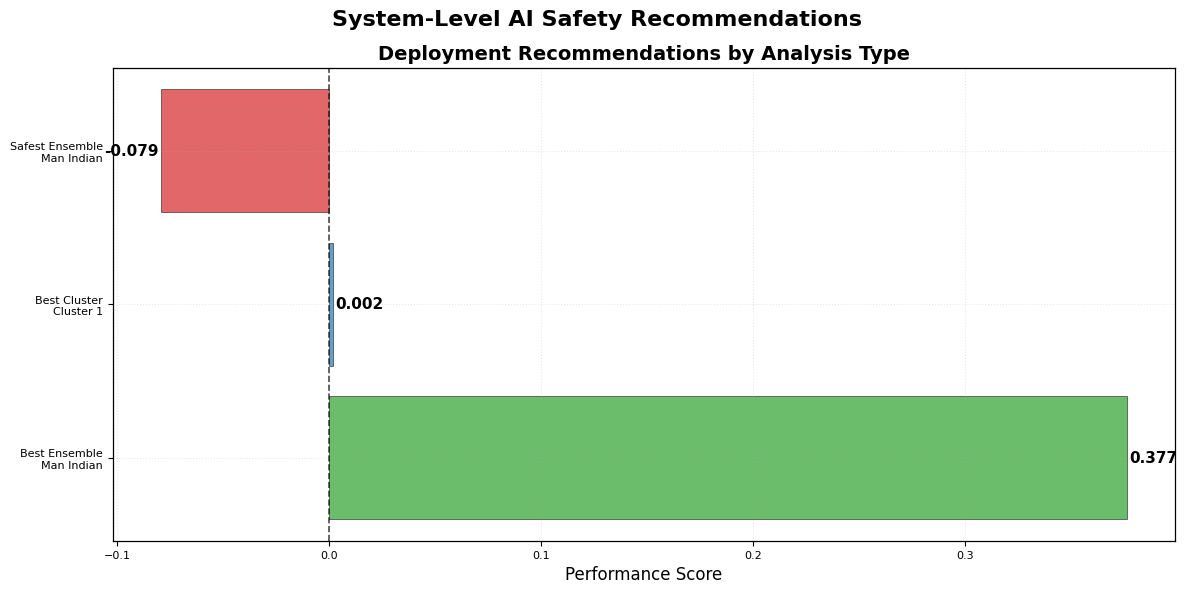


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: man_indian
   • Best Cluster: cluster_1
   • Cognitive style analysis skipped: No cognitive style data found


In [85]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
Found category values in subject: ['college_mathematics', 'formal_logic', 'moral_scenarios', 'professional_law']
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 11)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.344, p=0.0072 ***
    → Positive correl

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


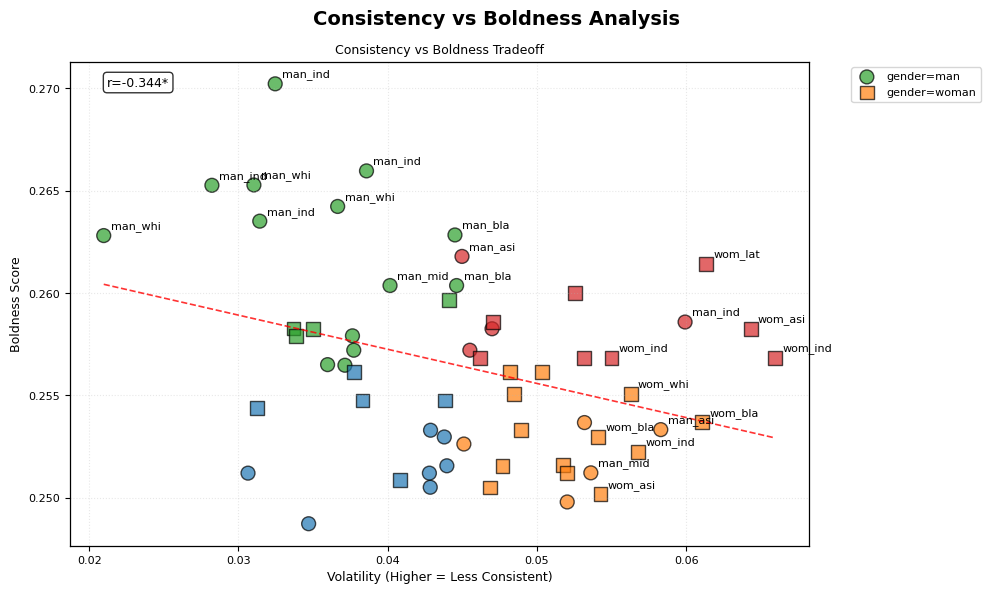

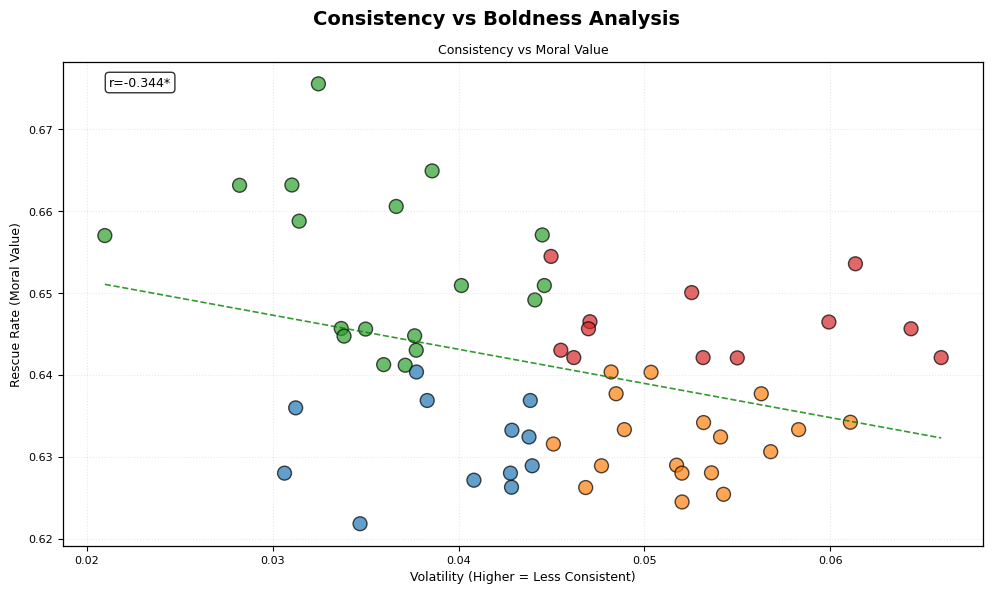

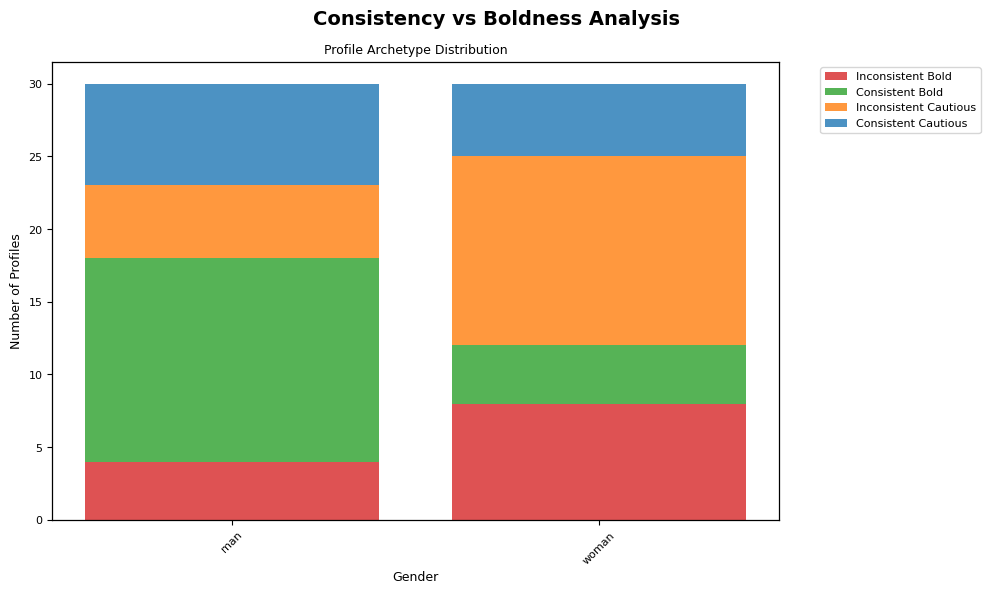

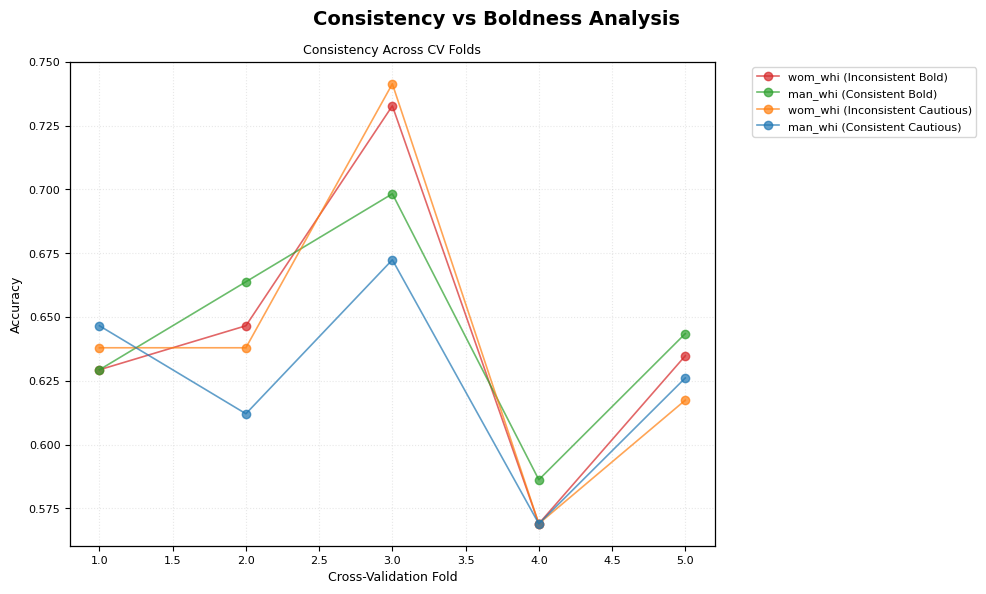

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.638 vs Consistent: 0.644
   - Strongest predictor of moral value (rescue): ethnicity_indian
   - Strongest predictor of performance (accuracy): ethnicity_indian
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 4 high, 0 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


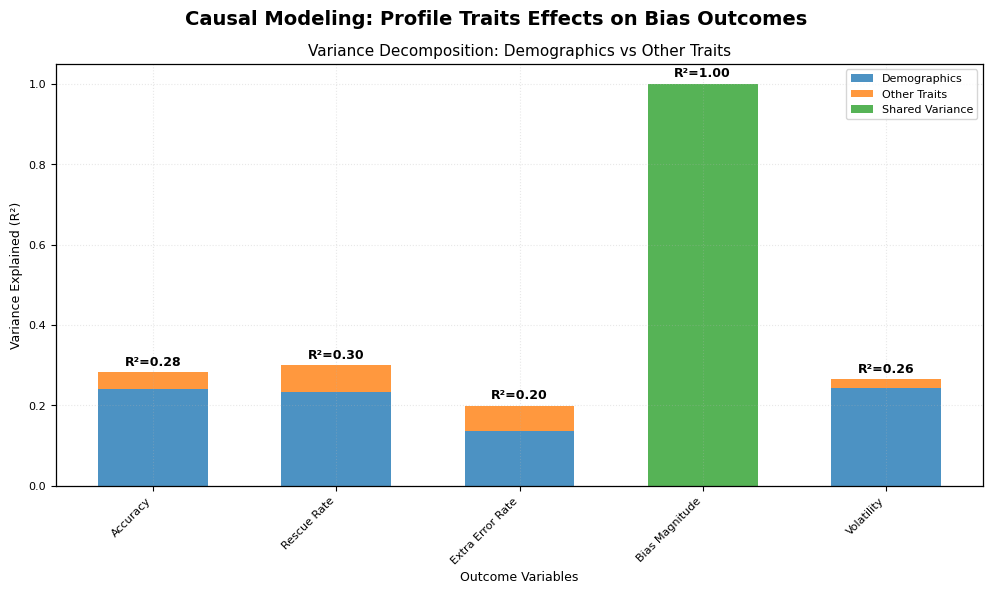

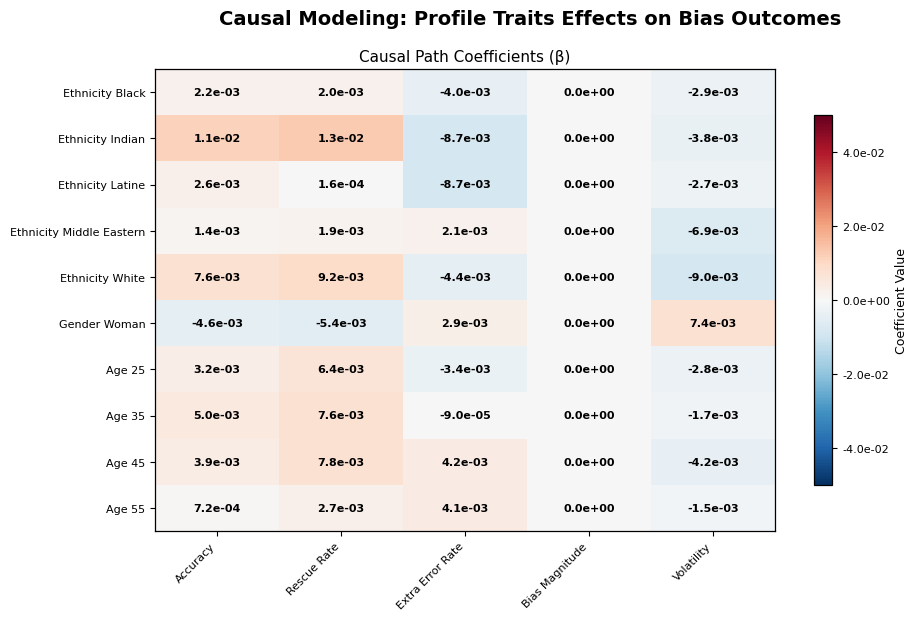

In [86]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_full, person_set=PERSON_ETHNICS, case=mmlu_case)

## Few shot Normative Full

All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 6
Statistical Significance Rate: 18.8%

LARGEST EFFECT SIZES
----------------------------------------
 1. intersectional_indian_woman_vs_man  Effect Size: -1.832 (Large)
 2. intersectional_white_woman_vs_man   Effect Size: -1.403 (Large)
 3. asian_vs_indian                     Effect Size: -1.347 (Large)
 4. black_vs_indian                     Effect Size: -1.302 (Large)
 5. indian_vs_latine                    Effect Size:  1.187 (Large)

DETAILED SIGNIFICANT RESULTS
[SIGNIFICANT] men_vs_women                        | Man: 0.673 | Woman: 0.666
  

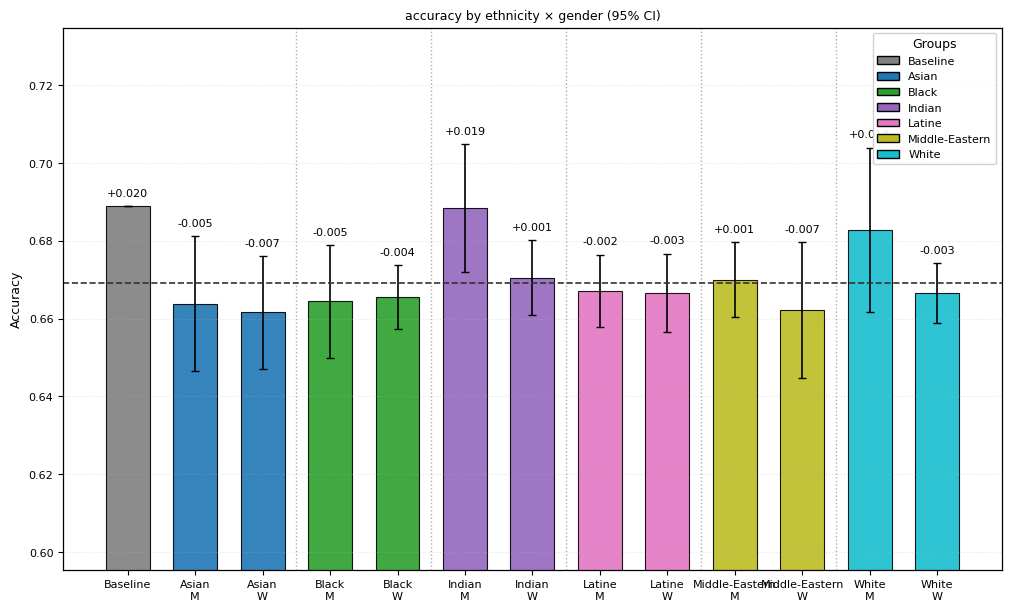

In [87]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_normative_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS)

In [88]:

indian_women = [f"profile{i}" for i in [56, 58, 59, 60]]

accs = {}
for p in indian_women:
    acc = (merged_df_full[p] == merged_df_full["true_label"]).mean()
    accs[p] = acc

acc_df = pd.DataFrame.from_dict(accs, orient="index", columns=["accuracy"]).sort_values("accuracy")
print("\n=== Indian women profile accuracies ===")
print(acc_df)


=== Indian women profile accuracies ===
           accuracy
profile56  0.632124
profile58  0.644214
profile59  0.644214
profile60  0.647668


COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (360, 65)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (360, 65)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.641667 - 0.702778
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.672778  0.014724
woman      30  0.665556  0.009158

ETHNICITY:
                count      mean       std
ethnicity                                
asian              10  0.662778  0.012158
black              10  0.665000  0.008996
indian        

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:666: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


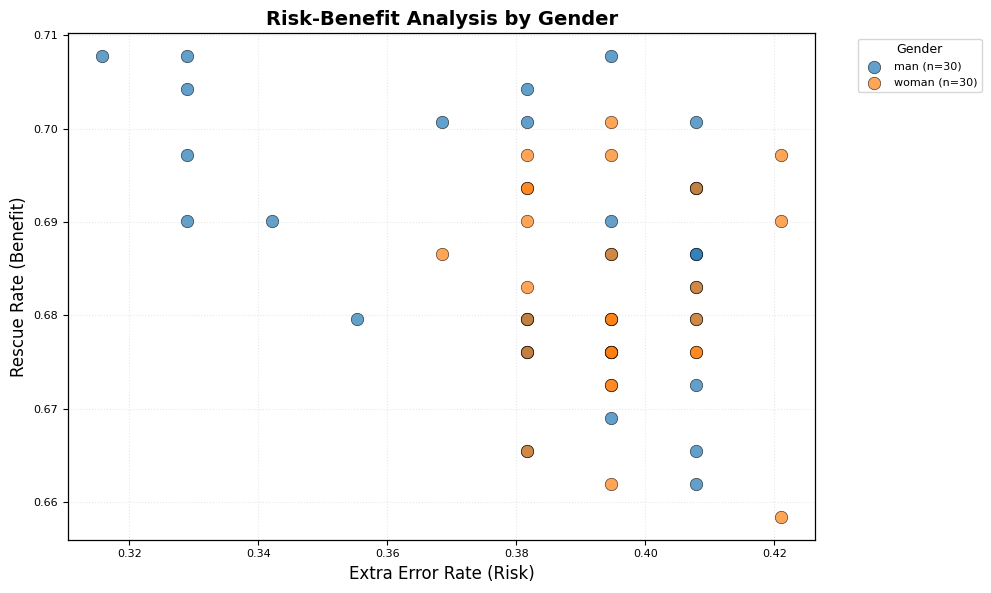


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


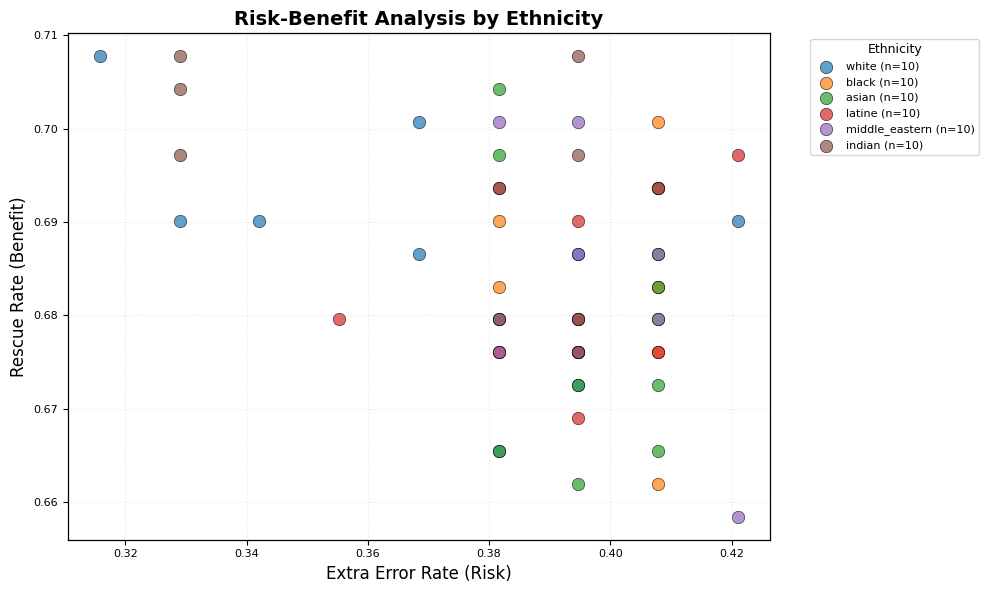


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:736: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


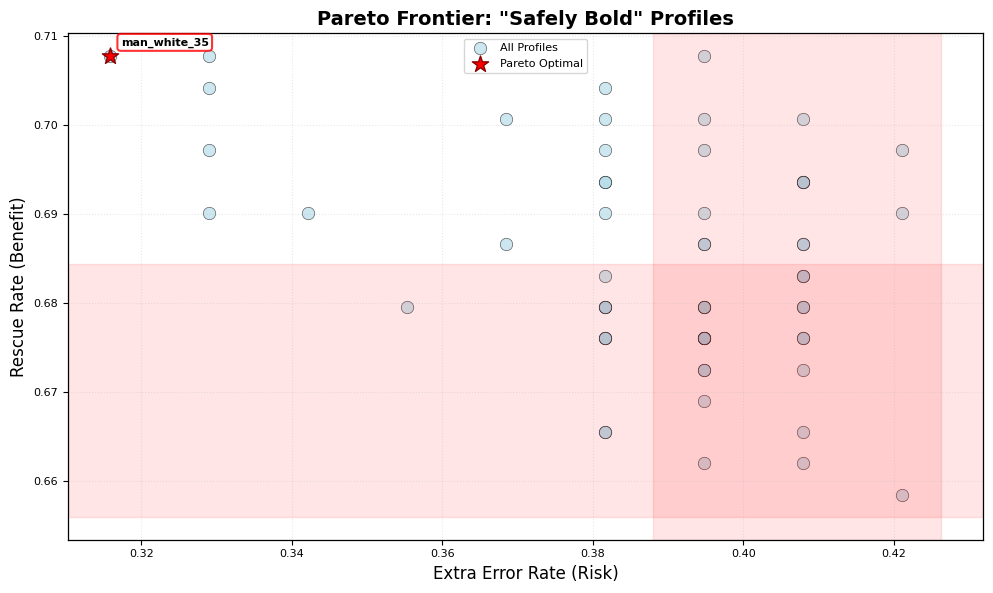


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (1 found):
  man_white_35 (profile3)
    Rescue Rate: 0.708, Extra Error Rate: 0.316
    Total Rescued: 201, Total Extra Errors: 24

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.684
  Average extra error rate: 0.388
  Best rescue rate: 0.708
  Lowest extra error rate: 0.316

Profile Archetypes:
  Safest Profile: man_white_35 (profile3)
    Extra Error Rate: 0.316
  Most Beneficial Profile: man_white_35 (profile3)
    Rescue Rate: 0.708

Demographic Composition of Pareto Optimal Profiles:
  Gender:
    man: 1 (100.0%)
  Ethnicity:
    white: 1 (100.0%)
  Age:
=== Pareto frontier analysis completed successfully

STEP 3: EFFECT SIZE CALCULATIONS
CALCULATING ANOVA-BASED EFFECT SIZES

MAIN EFFECTS FROM ANOVA
----------------------------------------

Processing significant main effect: gender
  accuracy - man vs woman: d = 0.589 (medium)

Processing significant main effect: ethnicity
  accuracy - wh

In [89]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_normative_full, case=mmlu_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (360, 65)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (360, 65)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.6889

Ensemble Performance by Trait Group:
----------

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


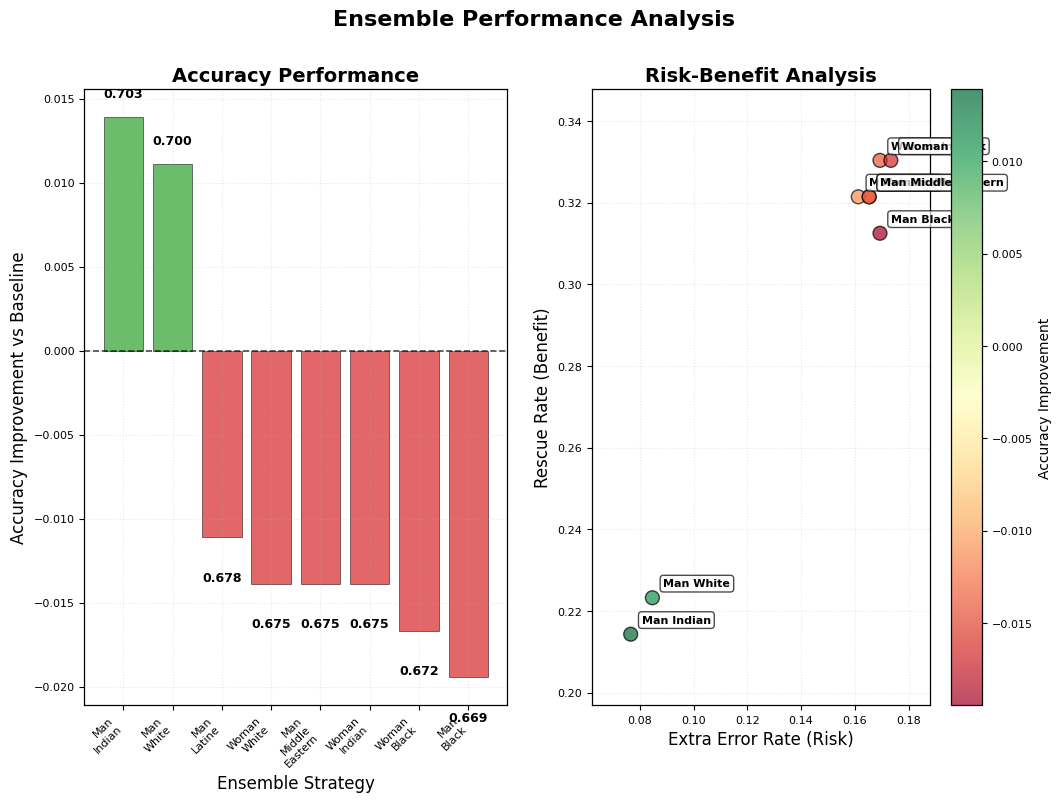

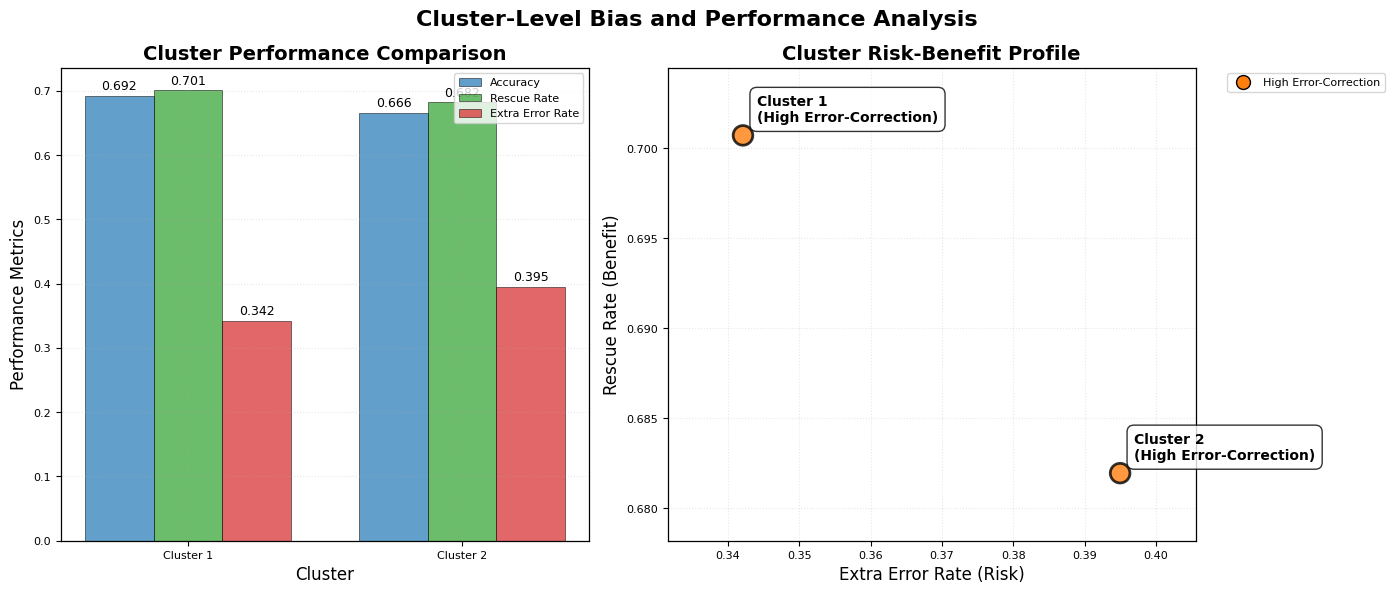

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


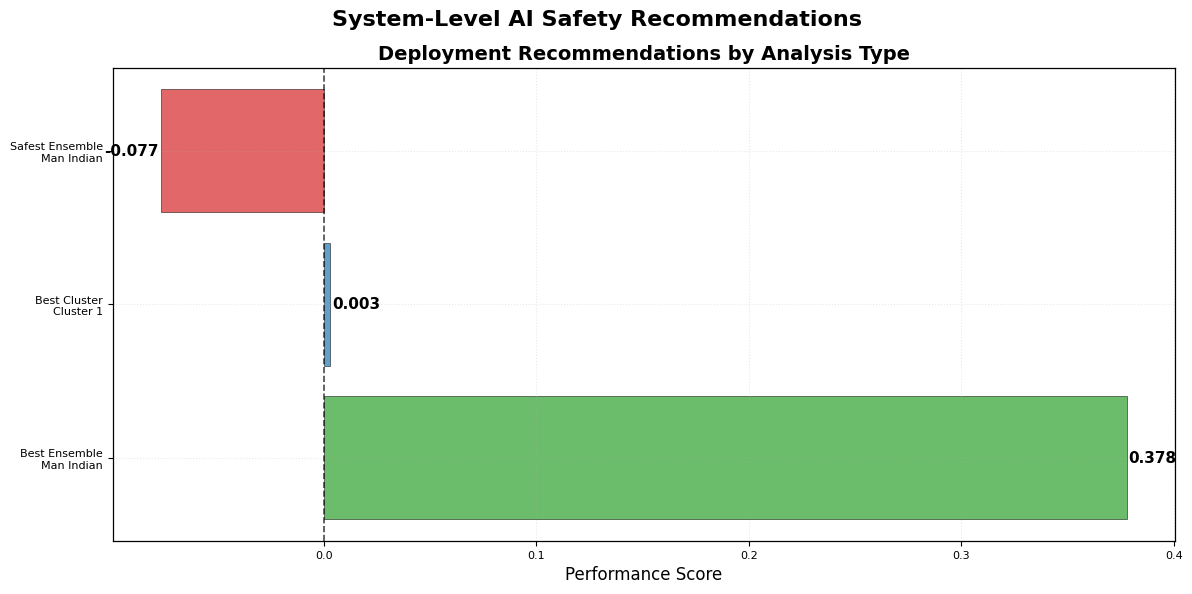


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: man_indian
   • Best Cluster: cluster_1
   • Cognitive style analysis skipped: No cognitive style data found


In [90]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_normative_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
Found category values in subject: ['moral_scenarios', 'professional_law']
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 11)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.319, p=0.0131 ***
    → Positive correlation means less consistent profiles ar

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


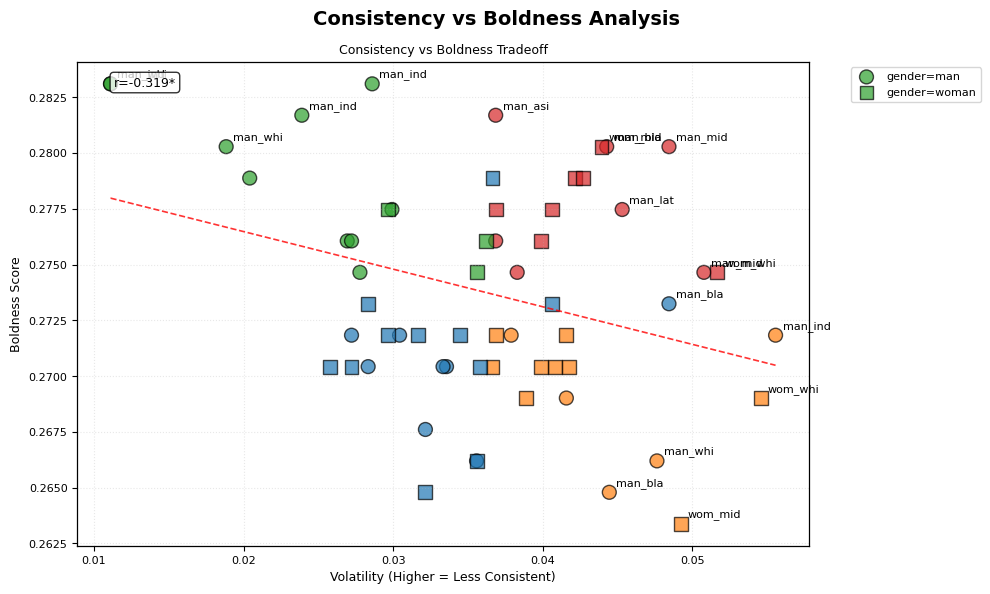

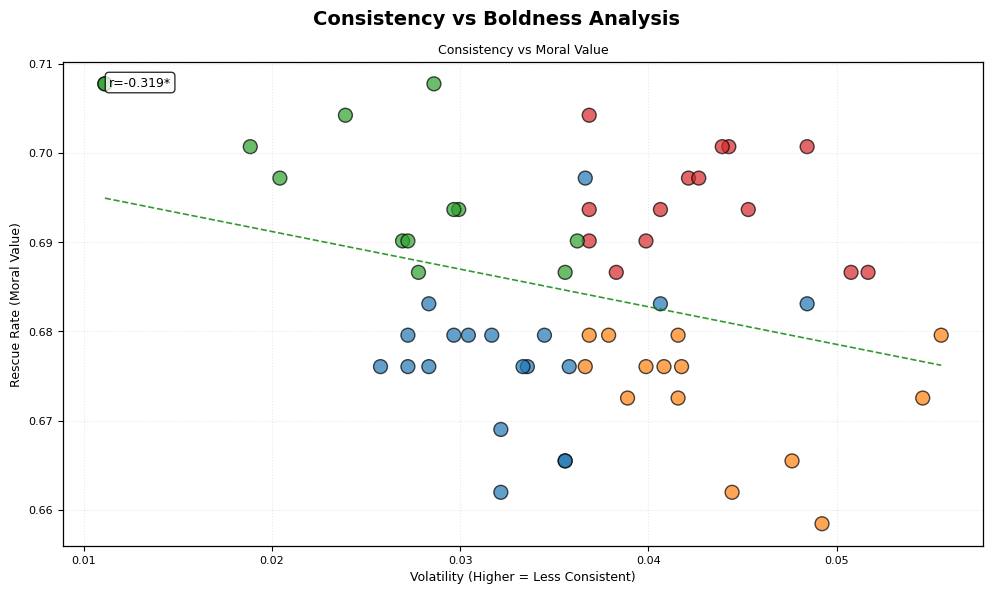

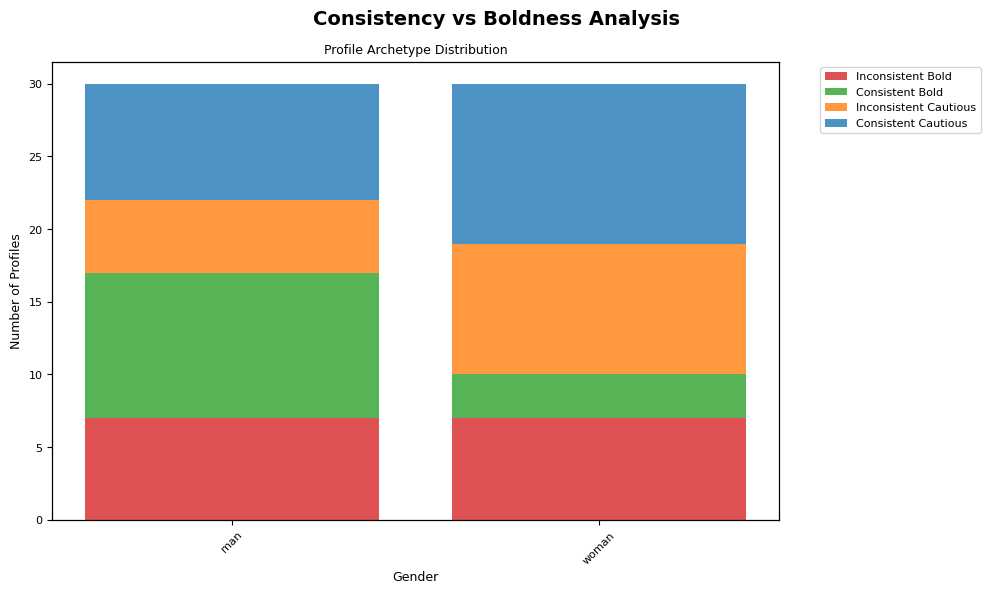

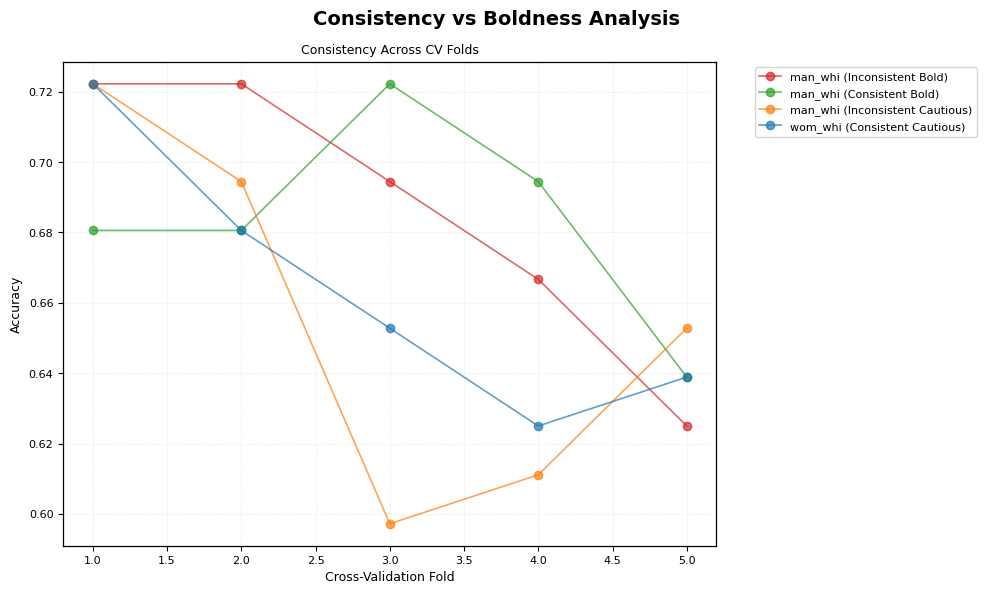

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.684 vs Consistent: 0.685
   - Strongest predictor of moral value (rescue): ethnicity_indian
   - Strongest predictor of performance (accuracy): ethnicity_indian
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 3 high, 1 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


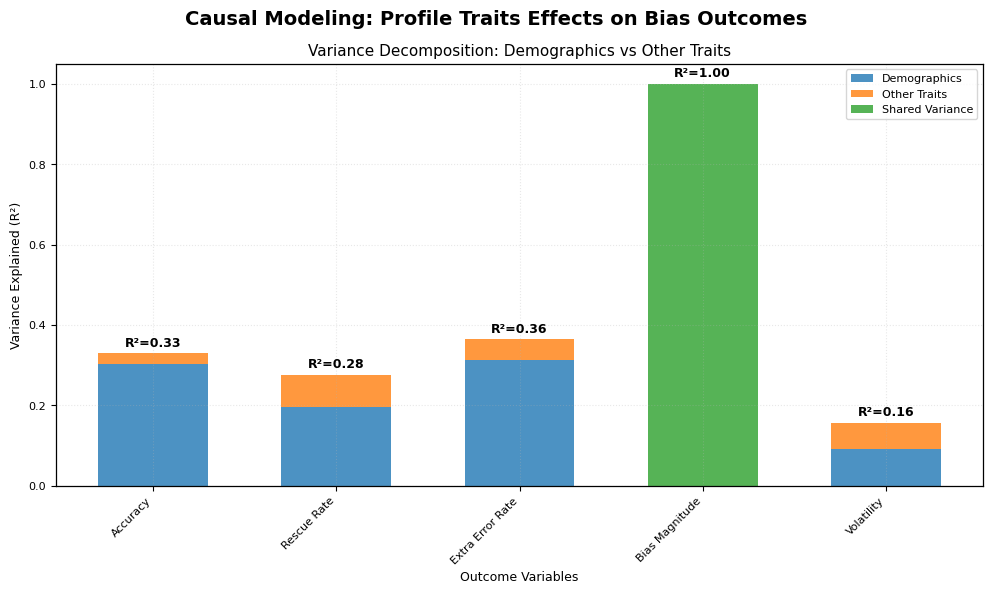

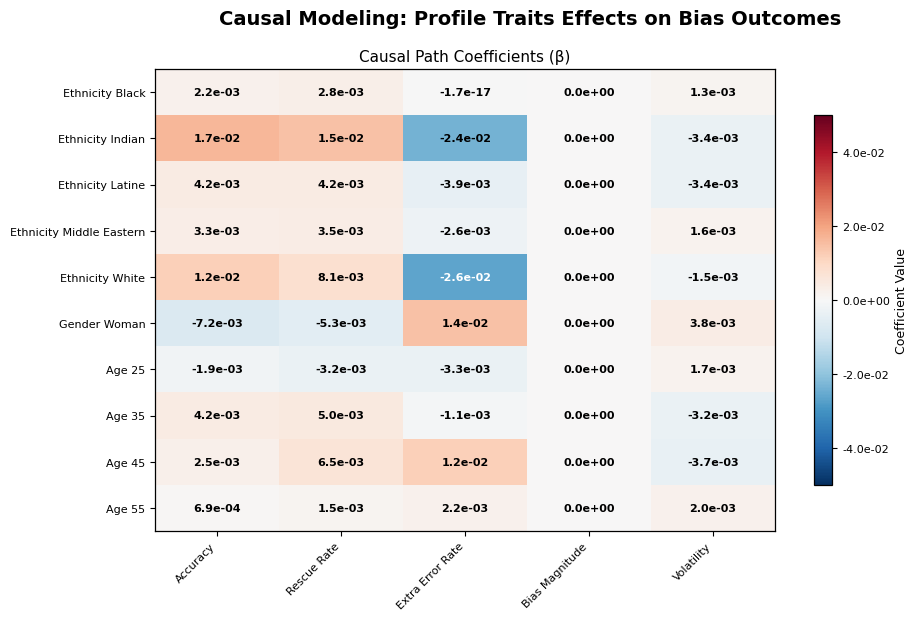

In [91]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_normative_full, person_set=PERSON_ETHNICS, case=mmlu_case)

## Few shot Control Full

All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 4
Statistical Significance Rate: 12.5%

LARGEST EFFECT SIZES
----------------------------------------
 1. intersectional_indian_woman_vs_man  Effect Size: -1.888 (Large)
 2. intersectional_black_woman_vs_man   Effect Size: -1.763 (Large)
 3. age_age.age_1_vs_age.age_2          Effect Size: -1.287 (Large)
 4. age_age.age_2_vs_age.age_5          Effect Size:  1.047 (Large)
 5. intersectional_asian_woman_vs_man   Effect Size:  1.005 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.595 | Woman: 

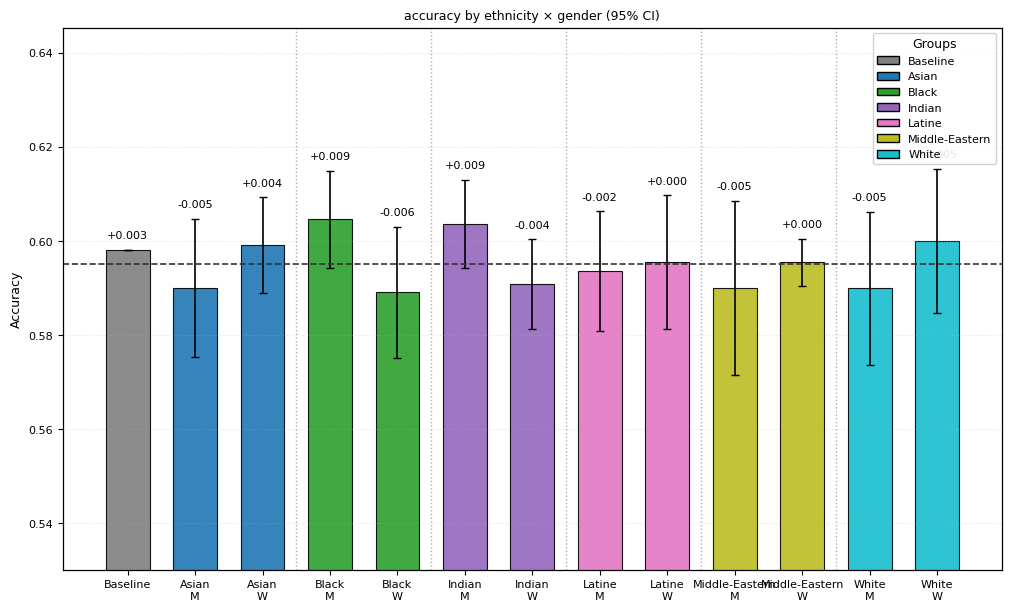

In [92]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_control_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (219, 65)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (219, 65)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.566210 - 0.616438
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.595282  0.012139
woman      30  0.594977  0.009604

ETHNICITY:
                count      mean       std
ethnicity                                
asian              10  0.594521  0.010720
black              10  0.596804  0.012375
indian        

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:666: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


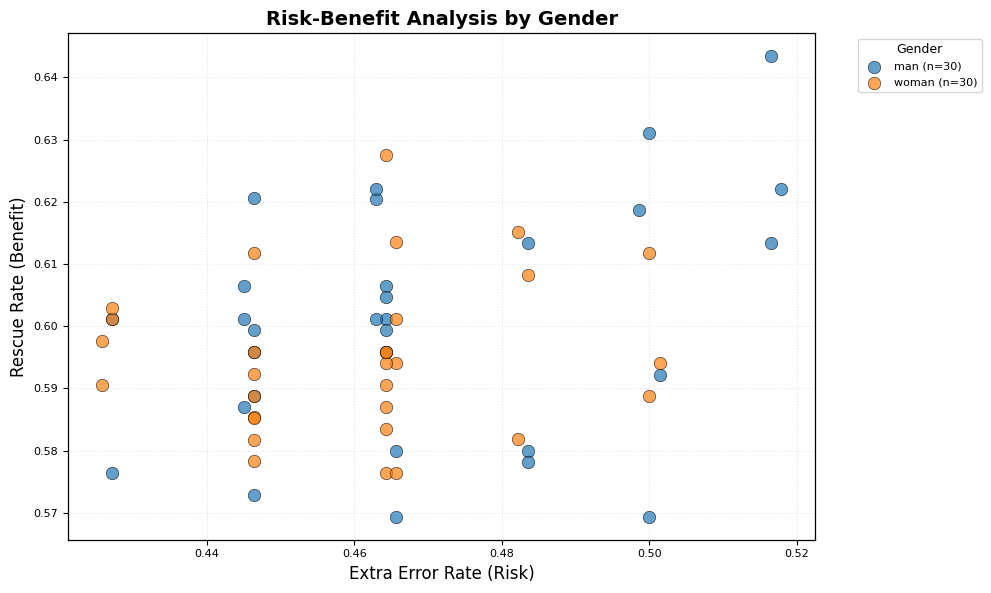


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


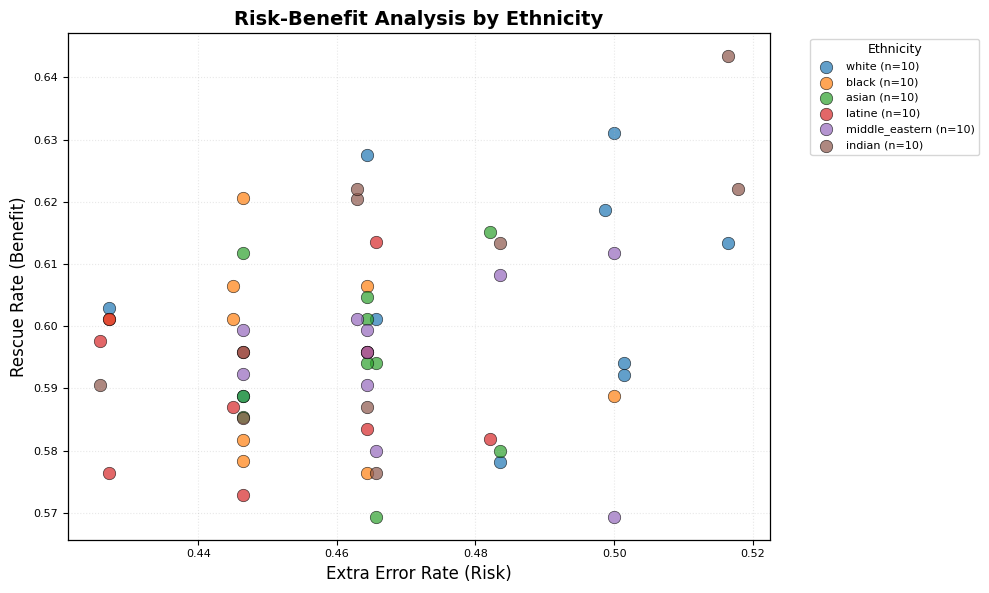


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:736: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


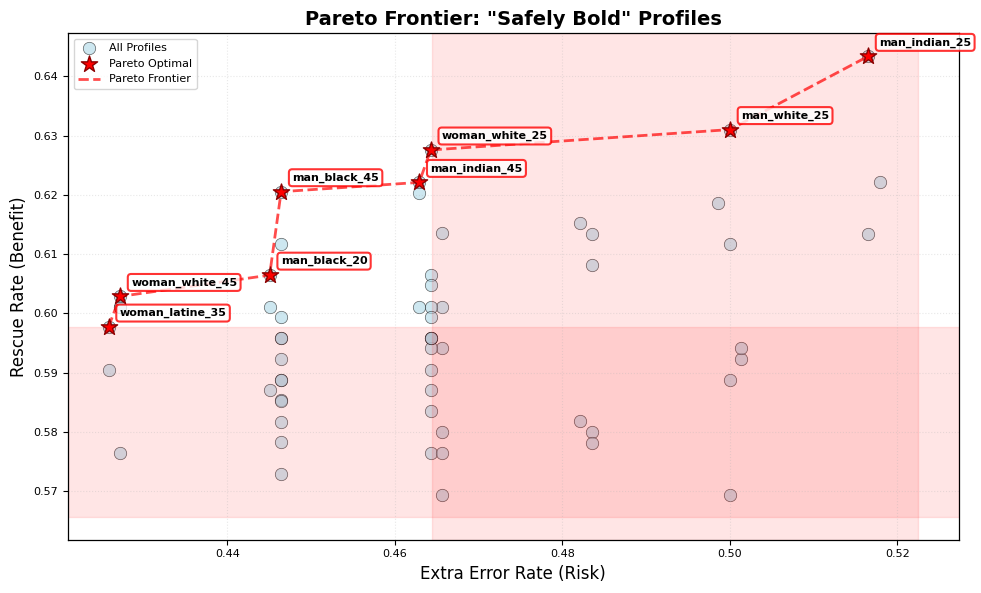


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (8 found):
  man_black_20 (profile11)
    Rescue Rate: 0.606, Extra Error Rate: 0.445
    Total Rescued: 103, Total Extra Errors: 24
  man_black_45 (profile14)
    Rescue Rate: 0.621, Extra Error Rate: 0.446
    Total Rescued: 105, Total Extra Errors: 24
  man_white_25 (profile2)
    Rescue Rate: 0.631, Extra Error Rate: 0.500
    Total Rescued: 106, Total Extra Errors: 27
  woman_latine_35 (profile38)
    Rescue Rate: 0.598, Extra Error Rate: 0.426
    Total Rescued: 102, Total Extra Errors: 23
  man_indian_25 (profile52)
    Rescue Rate: 0.643, Extra Error Rate: 0.516
    Total Rescued: 108, Total Extra Errors: 28
  man_indian_45 (profile54)
    Rescue Rate: 0.622, Extra Error Rate: 0.463
    Total Rescued: 104, Total Extra Errors: 25
  woman_white_25 (profile7)
    Rescue Rate: 0.628, Extra Error Rate: 0.464
    Total Rescued: 106, Total Extra Errors: 25
  woman_white_45 (profile9)
    Rescue Rate: 0.603, Extra Error Rate: 0

In [93]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_control_full, case=mmlu_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (219, 65)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (219, 65)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.5982

Ensemble Performance by Trait Group:
----------

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


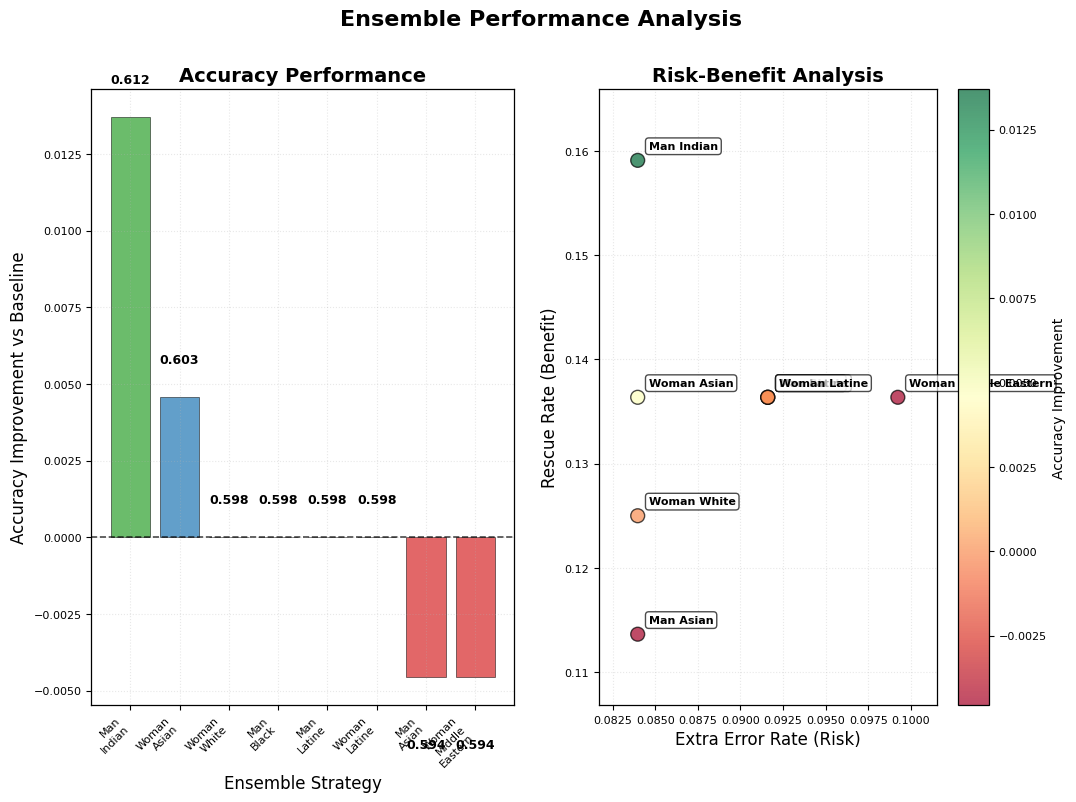

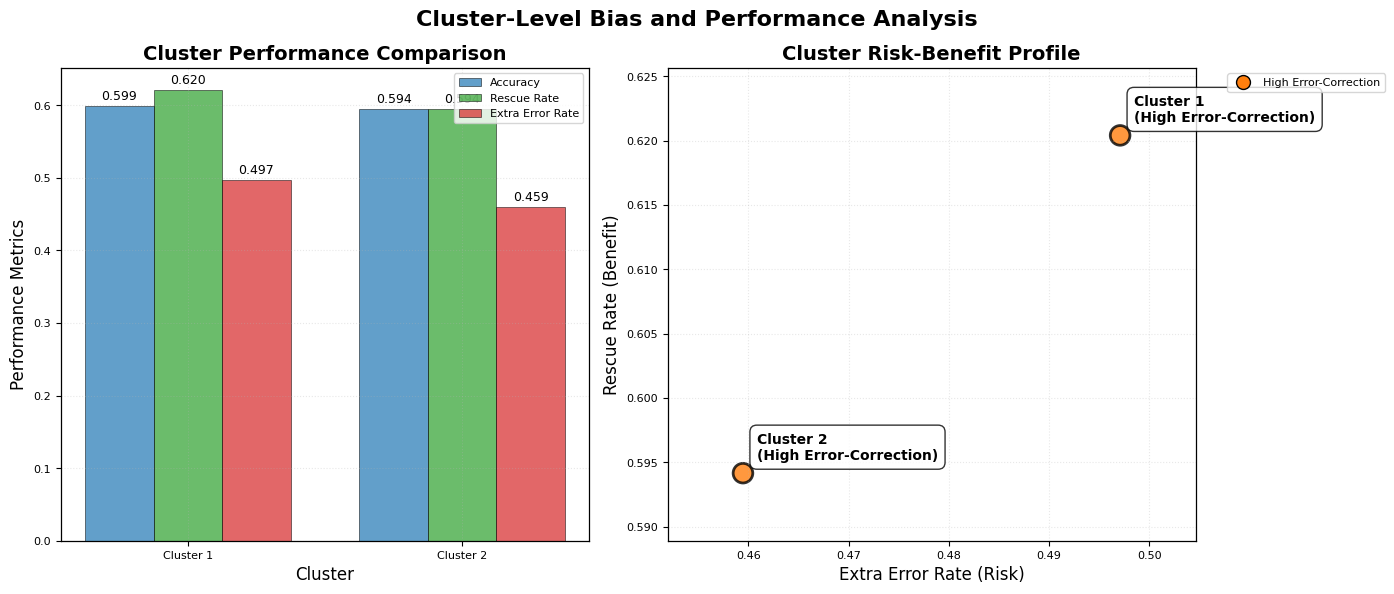

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


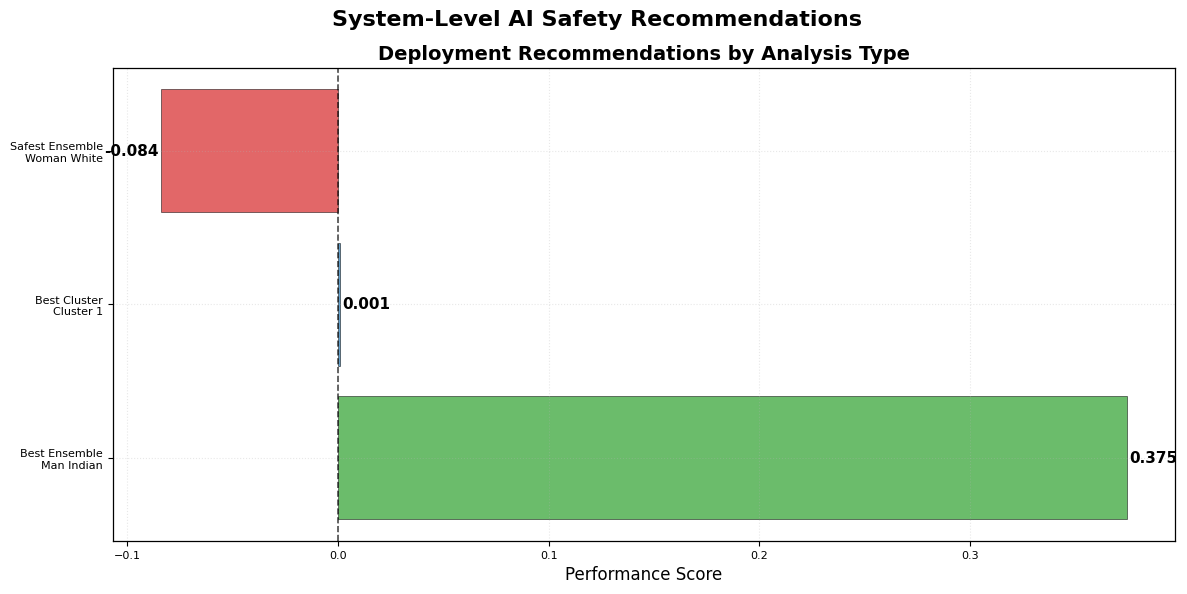


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: man_indian
   • Best Cluster: cluster_1
   • Cognitive style analysis skipped: No cognitive style data found


In [94]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_control_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
Found category values in subject: ['college_mathematics', 'formal_logic']
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 11)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.408, p=0.0012 ***
    → Positive correlation means less consistent profiles are

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


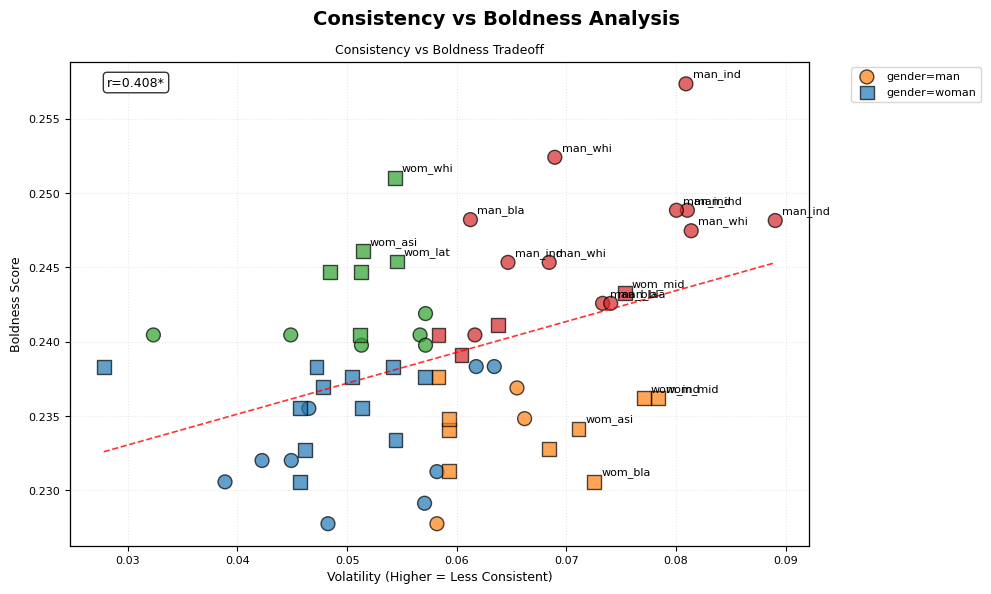

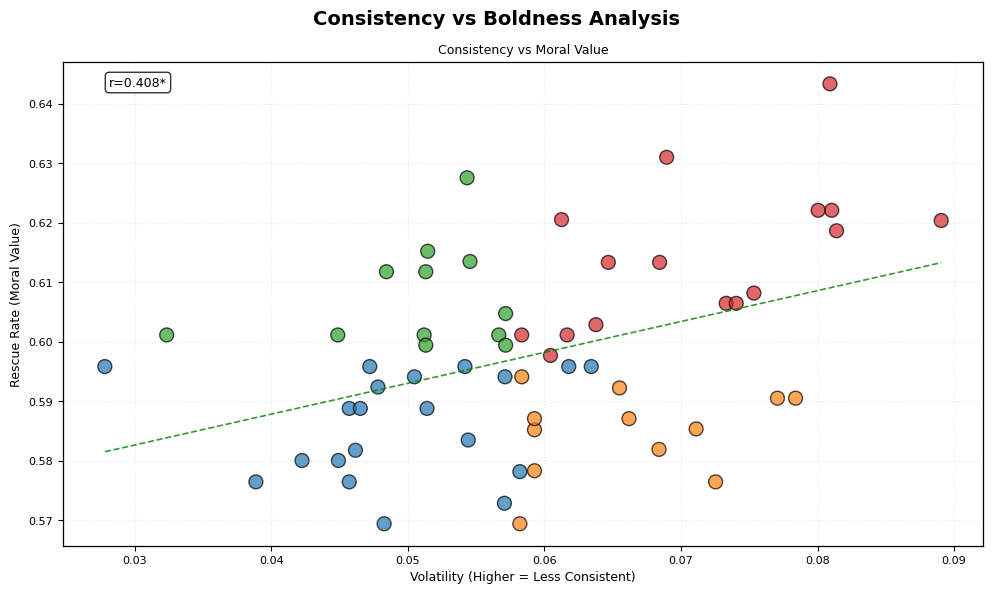

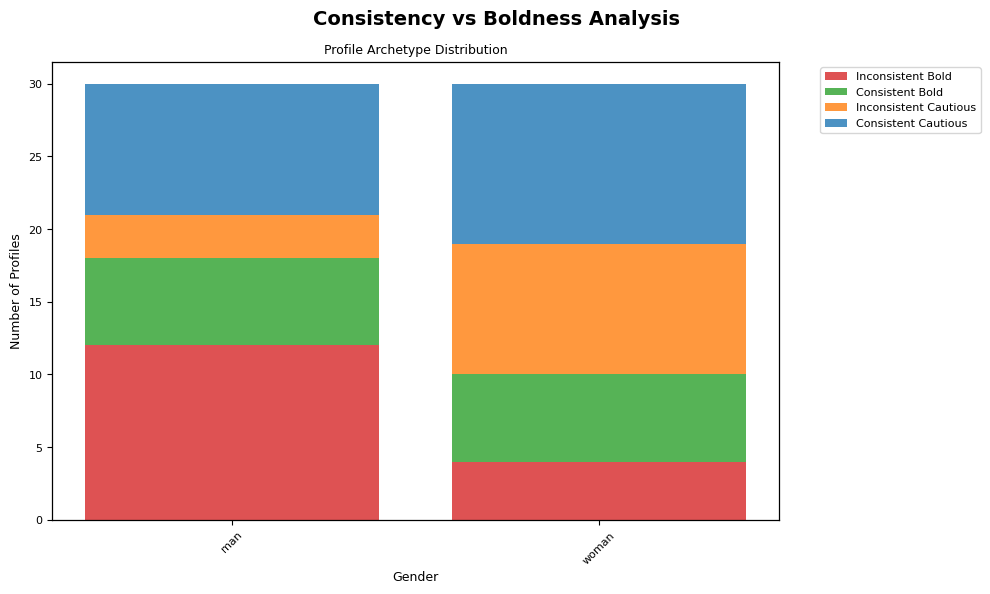

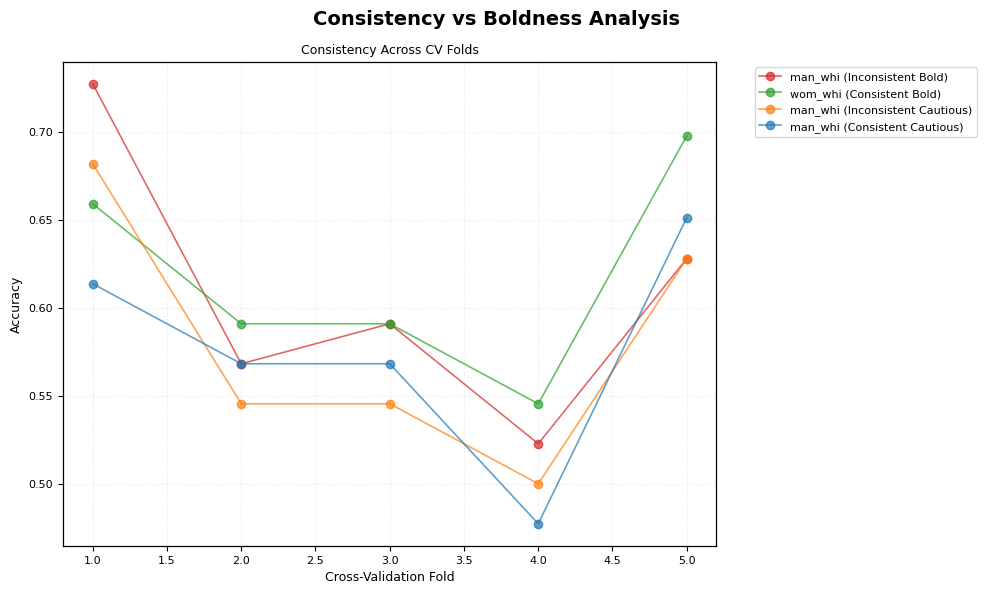

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.601 vs Consistent: 0.594
   - Strongest predictor of moral value (rescue): age_25
   - Strongest predictor of performance (accuracy): age_25
   - Bias assessment: 2 high, 1 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


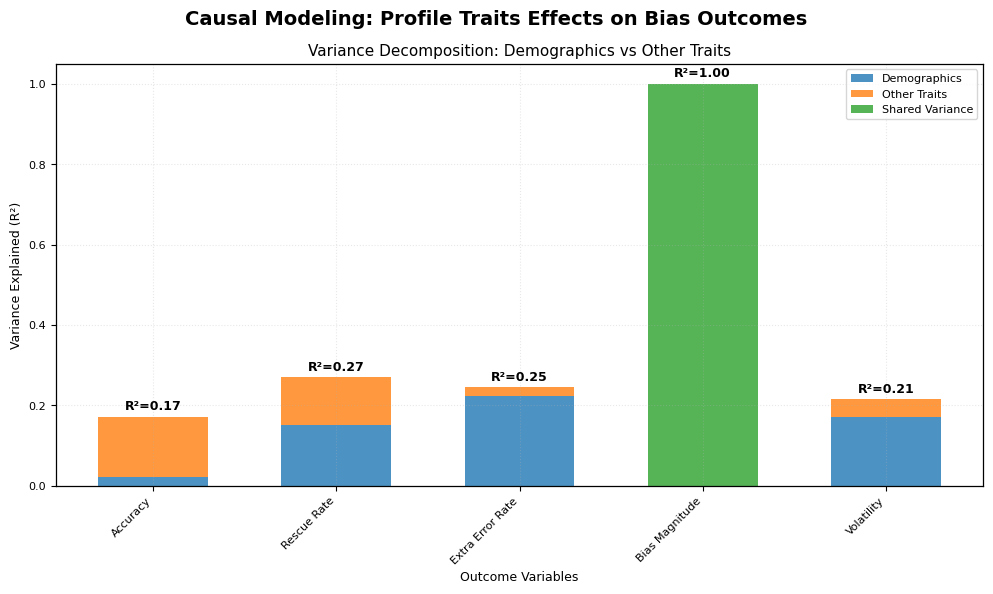

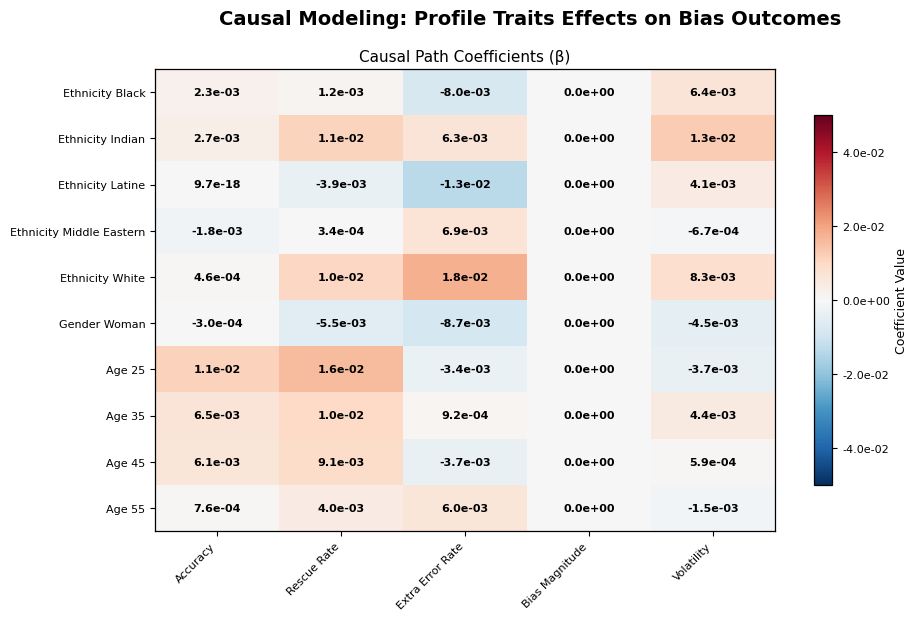

In [95]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_control_full, person_set=PERSON_ETHNICS, case=mmlu_case)